# Proyecto 2 — Análisis Exploratorio

**Curso:** CC3084 — Data Science · Universidad del Valle de Guatemala
**Semestre:** II — 2026

**Reto (Tema 3):** *A Step Ahead of Drought: Forecasting Global Water Storage Challenge*
organizado por la **ITU (International Telecommunication Union)** junto con agencias
del Sistema de Naciones Unidas, alojado en la plataforma Zindi.

**Categoría:** Series de tiempo con datos satelitales.

**Integrantes:**

1. ______________________________
2. ______________________________
3. ______________________________
4. ______________________________

---

## 1. Introducción

Este cuaderno desarrolla el análisis exploratorio de datos (EDA) del reto
*A Step Ahead of Drought*. El objetivo de esta etapa **no es construir el modelo
de pronóstico**, sino entender el fenómeno, la estructura del conjunto de datos y
los patrones que después permitirán plantear un modelo con criterio.

El documento está organizado de la siguiente manera. Las secciones 2 a 5 plantean
el problema: el contexto físico y satelital, la situación problemática que da
origen al reto, el problema científico y los objetivos. Las secciones 6 a 11
describen y preparan los datos. Las secciones 12 a 20 constituyen el análisis
exploratorio propiamente dicho, con énfasis en el comportamiento temporal por
tratarse de una serie de tiempo. Las secciones 21 a 23 resumen los hallazgos, las
conclusiones y los siguientes pasos.

### Nota sobre las fuentes

A lo largo del cuaderno se distingue de forma explícita entre dos tipos de
afirmación:

- **Evidencia del conjunto de datos.** Todo lo que se sostiene con una tabla, una
  estadística o una gráfica calculada en este mismo cuaderno.
- **Información externa.** Contexto tomado de la documentación oficial del reto o
  de literatura científica sobre GRACE, TWS y sequías. Aparece siempre con su
  referencia y se recopila en la sección de referencias.

Ninguna conclusión del análisis se apoya únicamente en información externa.

## 2. Contexto del problema

Esta sección corresponde a la investigación previa solicitada en la guía del
proyecto. Su información proviene de fuentes externas —documentación del reto y
literatura científica— y sirve para saber **qué buscar** durante el análisis
exploratorio.

### 2.1 ¿Qué fenómeno se está estudiando?

Se estudia la variación temporal del **agua almacenada en los continentes** y su
relación con la aparición de condiciones de sequía. No se trata únicamente de la
lluvia: se trata del balance acumulado entre el agua que entra a un territorio y
el agua que sale de él.

### 2.2 ¿Qué significa *Global Water Storage* en este reto?

El reto trabaja con el **Total Water Storage (TWS)**, definido en la propia
descripción de la competencia como *todo el agua almacenada sobre y bajo la
superficie terrestre*, lo que incluye:

| Componente         | Descripción                                          |
| ------------------ | ---------------------------------------------------- |
| Agua subterránea   | Acuíferos                                            |
| Humedad del suelo  | Agua retenida en la zona no saturada                 |
| Agua superficial   | Ríos, lagos, embalses, humedales                     |
| Nieve y hielo      | Acumulación estacional y glaciares                   |

El TWS se mide como una **anomalía**: no es un volumen absoluto, sino la
desviación respecto a una línea base histórica, expresada habitualmente en
centímetros o milímetros de **lámina de agua equivalente**. Un valor negativo
indica que hay menos agua almacenada que en el periodo de referencia.

Esta característica es importante para el análisis: una variable de anomalía está
**centrada alrededor de cero por construcción**, y esa es una expectativa que el
EDA debe verificar en los datos reales en lugar de darla por sentada.

### 2.3 El papel de los datos satelitales

El TWS a escala global se obtiene de las misiones **GRACE** (*Gravity Recovery and
Climate Experiment*, 2002–2017) y **GRACE-FO** (*GRACE Follow-On*, desde 2018).
Estas misiones no observan el agua directamente: miden variaciones muy pequeñas
del **campo gravitatorio terrestre**. Como el agua tiene masa, un cambio en la
cantidad de agua almacenada en una región cambia localmente la gravedad, y de esa
señal se deriva el TWS.

Esto tiene tres consecuencias prácticas que condicionan el análisis:

1. **Resolución espacial gruesa.** El producto es representativo de escalas del
   orden de cientos de kilómetros, no de una parcela o una cuenca pequeña.
2. **Resolución temporal mensual.** La serie es mensual, no diaria.
3. **Es una medida integrada en profundidad.** Suma agua superficial y subterránea,
   por lo que responde con más inercia que la lluvia o la humedad superficial del
   suelo.

### 2.4 ¿Por qué importa anticipar las sequías?

La sequía es un fenómeno de instalación lenta: cuando resulta visible en los
cultivos, en los caudales o en los pozos, el déficit lleva meses acumulándose.
Disponer de una estimación anticipada del almacenamiento de agua permite tomar
decisiones —restricciones de riego, gestión de embalses, alertas tempranas—
mientras todavía tienen efecto.

El TWS es particularmente útil aquí porque, al integrar el agua subterránea,
detecta **sequía hidrológica**, que es la que afecta el abastecimiento y que los
indicadores de respuesta rápida no capturan por sí solos.

### 2.5 ¿Qué se intenta pronosticar y por qué es un problema de series de tiempo?

De acuerdo con la descripción oficial del reto, la tarea consiste en predecir el
**TWS del mes siguiente** (`t+1`) a partir de información disponible en el mes `t`.
La motivación es la **latencia**: los productos derivados de GRACE se publican
con un retraso de aproximadamente 2 a 3 meses, de modo que el estado hídrico
"actual" no se conoce cuando se necesita.

Es un problema de series de tiempo por tres razones:

- La variable objetivo está **indexada en el tiempo** con frecuencia mensual y
  ordenada; el orden de las observaciones tiene significado.
- Existe **dependencia temporal**: el almacenamiento de un mes está fuertemente
  condicionado por el del mes anterior, dado que el agua se acumula y se agota de
  forma gradual.
- Se espera **estacionalidad** ligada al ciclo anual de lluvias, deshielo y
  evapotranspiración.

Formalmente es un problema de **regresión supervisada sobre datos
espacio-temporales**: para cada celda geográfica y cada mes se predice un valor
continuo. La métrica de evaluación del reto es el **RMSE**.

### 2.6 Covariables consideradas en el reto

La documentación del reto indica que, además del propio TWS, el conjunto de datos
incorpora indicadores climáticos con menor latencia que sirven como covariables:

- **SPEI** (*Standardised Precipitation-Evapotranspiration Index*) en varias
  escalas de acumulación (1, 3, 6 y 12 meses). Es un índice estandarizado que
  combina precipitación y evapotranspiración potencial. Los valores negativos
  indican déficit hídrico. Las escalas cortas reflejan sequía meteorológica y
  agrícola; las escalas largas se aproximan más a la sequía hidrológica.
- **Humedad del suelo** cercana a la superficie, que responde con rapidez a la
  lluvia y a la demanda evaporativa.

La expectativa razonable —que el análisis debe **verificar, no asumir**— es que las
escalas largas del SPEI se asocien más al TWS que las escalas cortas, precisamente
por la inercia del almacenamiento subterráneo.

> Las columnas concretas, sus nombres y sus unidades se verifican directamente
> sobre los archivos en la sección 8. En este cuaderno no se describe ninguna
> variable que no se haya observado en los datos.

## 3. Situación problemática

El agua dulce disponible para los ecosistemas y para la actividad humana no está
distribuida de manera uniforme ni es constante en el tiempo. Su disponibilidad
depende del balance entre lo que se recibe por precipitación y lo que se pierde por
evapotranspiración y escorrentía, y ese balance se acumula durante meses o años en
el suelo, en los cuerpos de agua superficiales y en los acuíferos. Cuando el
balance permanece negativo durante un periodo prolongado, el resultado es una
**sequía hidrológica**: una reducción sostenida del agua efectivamente almacenada
en un territorio.

El problema práctico es que esta reducción **no se observa con facilidad**. La
lluvia se mide bien, pero la lluvia por sí sola no describe el estado del sistema:
una región puede recibir precipitación normal y seguir agotándose si la demanda
evaporativa es alta o si la extracción de agua subterránea excede la recarga.
Medir directamente el agua almacenada requeriría una red de observación
—piezómetros, aforos, sensores de humedad— que a escala global no existe con
cobertura ni homogeneidad suficientes.

Aquí es donde los **datos satelitales** cambian el planteamiento. Las misiones
GRACE y GRACE-FO permiten estimar el almacenamiento total de agua de forma
indirecta, a partir de las variaciones del campo gravitatorio terrestre, con
cobertura global y de manera consistente en el tiempo. Por primera vez se dispone
de una variable comparable entre regiones que integra agua superficial y
subterránea, y que resulta adecuada para caracterizar el estado hídrico de grandes
territorios.

Sin embargo, esta solución trae consigo una limitación operativa. Según la
descripción del reto, los productos derivados de GRACE se publican con un
**retraso de aproximadamente 2 a 3 meses**. Ese desfase es determinante: para
monitoreo y alerta temprana se necesita conocer el estado actual del sistema, y lo
que está disponible es el estado de hace un trimestre. La información existe, pero
llega tarde para sostener una decisión.

De ahí surge la dificultad que motiva el reto. Anticipar el almacenamiento futuro
de agua no es trivial por varias razones que el análisis exploratorio debe
examinar:

- El comportamiento del agua almacenada **no es homogéneo en el espacio**. Una
  región tropical, una zona árida, una cuenca dominada por deshielo y una región
  con fuerte extracción de agua subterránea responden de maneras distintas, de
  modo que un patrón global promedio puede ocultar dinámicas opuestas.
- La señal combina al menos tres componentes —**tendencia de largo plazo,
  estacionalidad anual y variabilidad interanual**— que se superponen y que
  conviene separar antes de modelar.
- Las covariables disponibles con baja latencia, como el SPEI y la humedad del
  suelo, describen sobre todo la parte superficial y de respuesta rápida del ciclo
  hidrológico, mientras que el TWS incluye componentes de respuesta lenta. Su
  capacidad de anticipar el TWS es, por tanto, una **pregunta empírica**.
- Los registros satelitales presentan **interrupciones y valores faltantes**. En
  particular, entre el fin de la misión GRACE y el inicio de GRACE-FO existe un
  hueco en la serie, y su presencia debe verificarse en los datos del reto porque
  condiciona qué se puede modelar y con qué evidencia.

El análisis exploratorio busca precisamente caracterizar estos elementos con
evidencia, en lugar de darlos por conocidos.

## 4. Problema científico

> **¿Qué patrones temporales, estacionales y espaciales presenta la anomalía de
> almacenamiento total de agua (TWS) en el conjunto de datos del reto, y qué
> variables satelitales y climáticas disponibles en el mes actual muestran mayor
> asociación con el TWS del mes siguiente, de manera que puedan sustentar la
> construcción de un modelo de pronóstico a un mes de horizonte?**

La pregunta se puede responder con los datos disponibles porque cada uno de sus
componentes se traduce en un análisis concreto y verificable:

| Componente de la pregunta       | Cómo se responde                                                        |
| ------------------------------- | ----------------------------------------------------------------------- |
| Patrones temporales             | Serie agregada, medias móviles y comparación entre periodos (sección 16) |
| Patrones estacionales           | Perfil mensual, boxplots por mes y descomposición temporal (sección 17)  |
| Patrones espaciales             | Agregación por latitud y por región, y mapas de la rejilla (sección 18)  |
| Asociación entre variables      | Matriz de correlación y gráficos de dispersión (secciones 19 y 20)       |
| Utilidad para el pronóstico     | Asociación de la variable objetivo con el TWS actual y sus rezagos       |

Se trata de una pregunta **descriptiva y asociativa**, no causal. A lo largo del
cuaderno se habla de asociación o de correlación observada, nunca de causa: que
dos variables se muevan juntas no demuestra que una determine a la otra.

## 5. Objetivos

### 5.1 Objetivo general

Caracterizar, mediante un análisis exploratorio reproducible, el comportamiento
temporal, estacional y espacial de la anomalía de almacenamiento total de agua
(TWS) y de sus covariables en el conjunto de datos del reto
*A Step Ahead of Drought*, con el fin de identificar los patrones y las variables
que sustenten la construcción posterior de un modelo de pronóstico a un mes de
horizonte.

### 5.2 Objetivos específicos

1. **Describir** la estructura del conjunto de datos: número de observaciones y de
   variables, tipo de cada una, cobertura temporal y cobertura espacial,
   documentando la clasificación de las variables en identificadores, temporales,
   geográficas, satelitales y objetivo.

2. **Evaluar** la calidad de los datos cuantificando valores faltantes,
   observaciones duplicadas y valores extremos, y determinando si su presencia
   responde a patrones temporales o espaciales antes de tomar cualquier decisión
   de tratamiento.

3. **Analizar** el comportamiento temporal de la variable objetivo mediante
   estadística descriptiva, medias móviles y descomposición de la serie, para
   determinar la existencia de tendencia, estacionalidad y periodos anómalos.

4. **Comparar** el comportamiento del almacenamiento de agua entre distintas
   ubicaciones geográficas, para determinar si el patrón temporal global es
   representativo o si oculta dinámicas regionales diferentes.

5. **Determinar** el grado de asociación entre la variable objetivo, el
   almacenamiento del mes actual y las covariables climáticas disponibles,
   utilizando matrices de correlación y gráficos de dispersión.

6. **Identificar** las variables, transformaciones y estructuras temporales
   candidatas a ser utilizadas en la etapa posterior de modelado, con base en la
   evidencia obtenida en los objetivos anteriores.

Los seis objetivos son medibles: cada uno se cierra con una tabla, una gráfica o
un estadístico concreto dentro del cuaderno, y en la sección 22 se retoma cada uno
para verificar que fue cumplido.

## 6. Importación de librerías

Se utilizan las mismas librerías empleadas en los ejemplos y laboratorios del
curso: `pandas` y `numpy` para el manejo de datos, `matplotlib` y `seaborn` para
las visualizaciones, y `statsmodels` para la descomposición de la serie de tiempo
y la prueba de Dickey-Fuller, tal como se hizo en el ejemplo de series de tiempo
visto en clase. No se incorporan librerías adicionales que no aporten al análisis.

In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller

from IPython.display import display, Markdown

warnings.filterwarnings("ignore", category=FutureWarning)

# Opciones de despliegue: tablas legibles sin truncar columnas relevantes.
pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 160)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

# Estilo de gráficos consistente en todo el cuaderno.
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = (13, 5)
plt.rcParams["figure.dpi"] = 110
plt.rcParams["savefig.dpi"] = 160
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

# Semilla para que cualquier muestreo sea reproducible.
SEMILLA = 42
rng = np.random.default_rng(SEMILLA)

print(f"pandas      {pd.__version__}")
print(f"numpy       {np.__version__}")
print(f"matplotlib  {plt.matplotlib.__version__}")
print(f"seaborn     {sns.__version__}")

pandas      3.0.2
numpy       2.2.3
matplotlib  3.10.1
seaborn     0.13.2


In [2]:
# Rutas relativas al proyecto: el cuaderno se ejecuta desde la raíz del repositorio.
RAIZ = Path.cwd()
CRUDOS = RAIZ / "data" / "raw"
PROCESADOS = RAIZ / "data" / "processed"
FIGURAS = RAIZ / "figures"
TABLAS = RAIZ / "outputs" / "tablas"

for carpeta in (PROCESADOS, FIGURAS, TABLAS):
    carpeta.mkdir(parents=True, exist_ok=True)

print(f"Raíz del proyecto : {RAIZ}")
print(f"Datos crudos      : {CRUDOS.relative_to(RAIZ)}")
print(f"Figuras           : {FIGURAS.relative_to(RAIZ)}")


def guardar_figura(nombre):
    'Guarda la figura activa en figures/ para reutilizarla en informe y presentación.'
    plt.savefig(FIGURAS / f"{nombre}.png", bbox_inches="tight")

Raíz del proyecto : /Users/javiervalladares/Library/Mobile Documents/com~apple~CloudDocs/Octavo Semestre/Datos/Proyecto2
Datos crudos      : data/raw
Figuras           : figures


## 7. Carga de datos

Los archivos del reto se leen desde `data/raw/`. Son archivos grandes
—`Train.csv` pesa alrededor de 276 MB— por lo que antes de cargarlos se revisa
su tamaño y, una vez cargados, se reporta la memoria que ocupan. Si la huella de
memoria resulta excesiva se convierten las columnas de punto flotante a
`float32`, que para variables geofísicas conserva precisión más que suficiente y
reduce el consumo a la mitad.

Los archivos originales **no se modifican en ningún momento**: se leen y todo
producto derivado se guarda en `data/processed/`.

In [3]:
ARCHIVOS = {
    "Train": CRUDOS / "Train.csv",
    "Test": CRUDOS / "Test.csv",
}
# SampleSubmission solo define el formato de entrega; no interviene en el EDA.
OPCIONALES = {"SampleSubmission": CRUDOS / "SampleSubmission.csv"}

faltantes = [n for n, ruta in ARCHIVOS.items() if not ruta.exists()]
if faltantes:
    raise FileNotFoundError(
        "No se encontraron los archivos del reto: " + ", ".join(faltantes) + ".\n"
        "Descárguelos desde Zindi y colóquelos en data/raw/ "
        "siguiendo las instrucciones de data/raw/README.md."
    )

for nombre, ruta in {**ARCHIVOS, **OPCIONALES}.items():
    estado = f"{ruta.stat().st_size / 1024**2:8.1f} MB" if ruta.exists() else "no disponible"
    print(f"{nombre:18} {estado}")

Train                 275.7 MB
Test                   32.8 MB
SampleSubmission   no disponible


In [4]:
# Lectura completa. Se mide el tiempo porque Train.csv es grande.
train = pd.read_csv(ARCHIVOS["Train"], parse_dates=["time"])
test = pd.read_csv(ARCHIVOS["Test"], parse_dates=["time"])

print(f"train  {train.shape[0]:>10,} filas x {train.shape[1]:>2} columnas")
print(f"test   {test.shape[0]:>10,} filas x {test.shape[1]:>2} columnas")

train   2,154,021 filas x 13 columnas
test      280,961 filas x 13 columnas


In [5]:
# Huella de memoria antes de optimizar tipos.
def memoria_mb(df):
    return df.memory_usage(deep=True).sum() / 1024**2

print(f"Memoria train : {memoria_mb(train):8.1f} MB")
print(f"Memoria test  : {memoria_mb(test):8.1f} MB")

# Las variables geofísicas no requieren la precisión de float64.
columnas_float = train.select_dtypes("float64").columns
train[columnas_float] = train[columnas_float].astype("float32")
columnas_float_test = test.select_dtypes("float64").columns
test[columnas_float_test] = test[columnas_float_test].astype("float32")

print(f"\nDespués de convertir a float32:")
print(f"Memoria train : {memoria_mb(train):8.1f} MB")
print(f"Memoria test  : {memoria_mb(test):8.1f} MB")

Memoria train :    252.1 MB
Memoria test  :     31.0 MB

Después de convertir a float32:
Memoria train :    161.7 MB
Memoria test  :     20.3 MB


## 8. Descripción de los datasets

Esta sección documenta la estructura real de los archivos. Todo lo que se afirma
a partir de aquí proviene de los datos, no de la documentación del reto.

In [6]:
print("Columnas de train:")
print(list(train.columns))
print("\nColumnas de test:")
print(list(test.columns))

# Diferencia de columnas en ambos sentidos: identifica la variable objetivo y
# las columnas que solo existen en el conjunto de prueba.
solo_en_train = [c for c in train.columns if c not in test.columns]
solo_en_test = [c for c in test.columns if c not in train.columns]
print(f"\nSolo en train : {solo_en_train}")
print(f"Solo en test  : {solo_en_test}")

Columnas de train:
['sample_id', 'time', 'lat', 'lon', 'TWS_t', 'SPEI_01_t', 'SPEI_03_t', 'SPEI_06_t', 'SPEI_12_t', 'SOIL_MOISTURE_t', 'month_sin', 'month_cos', 'target']

Columnas de test:
['ID', 'time', 'lat', 'lon', 'TWS_t', 'SPEI_01_t', 'SPEI_03_t', 'SPEI_06_t', 'SPEI_12_t', 'SOIL_MOISTURE_t', 'month_sin', 'month_cos', 'TWS_t_masked']

Solo en train : ['sample_id', 'target']
Solo en test  : ['ID', 'TWS_t_masked']


In [7]:
print("Primeras observaciones de train:")
display(train.head())

print("Últimas observaciones de train:")
display(train.tail())

print("Primeras observaciones de test:")
display(test.head())

Primeras observaciones de train:


,sample_id,time,lat,lon,TWS_t,SPEI_01_t,SPEI_03_t,SPEI_06_t,SPEI_12_t,SOIL_MOISTURE_t,month_sin,month_cos,target
0,20020501_-55.5_-68.5,2002-05-01,-55.5000,-68.5000,0.8762,-1.5842,-1.7016,-2.0151,-1.9123,-1.8278,0.5000,-0.8660,0.2077
1,20020501_-55.5_-67.5,2002-05-01,-55.5000,-67.5000,0.9981,-1.5074,-1.5696,-2.4590,-2.1729,-2.0932,0.5000,-0.8660,0.6345
2,20020501_-54.5_-71.5,2002-05-01,-54.5000,-71.5000,0.8134,-1.4731,-1.1510,-0.5247,-0.9081,-0.9323,0.5000,-0.8660,-0.3371
3,20020501_-54.5_-70.5,2002-05-01,-54.5000,-70.5000,0.8419,-1.4608,-1.4880,-0.5885,-0.9368,-0.9284,0.5000,-0.8660,-0.1481
4,20020501_-54.5_-69.5,2002-05-01,-54.5000,-69.5000,0.8728,-1.2756,-1.7298,-0.2438,-0.8700,-1.0537,0.5000,-0.8660,0.0895


Últimas observaciones de train:


,sample_id,time,lat,lon,TWS_t,SPEI_01_t,SPEI_03_t,SPEI_06_t,SPEI_12_t,SOIL_MOISTURE_t,month_sin,month_cos,target
2154016,20150801_83.5_-31.5,2015-08-01,83.5000,-31.5000,-0.1293,0.1244,0.2723,0.2956,-0.4620,0.2597,-0.8660,-0.5000,-0.2740
2154017,20150801_83.5_-30.5,2015-08-01,83.5000,-30.5000,-0.1240,0.2014,0.2547,0.2518,-0.4742,0.1576,-0.8660,-0.5000,-0.2714
2154018,20150801_83.5_-29.5,2015-08-01,83.5000,-29.5000,-0.1187,0.2162,0.2099,0.2300,-0.4462,0.1135,-0.8660,-0.5000,-0.2685
2154019,20150801_83.5_-28.5,2015-08-01,83.5000,-28.5000,-0.1135,0.1029,0.2097,0.1653,-0.4174,-0.2486,-0.8660,-0.5000,-0.2654
2154020,20150801_83.5_-27.5,2015-08-01,83.5000,-27.5000,-0.1081,0.1665,0.1282,0.1208,-0.3381,0.0119,-0.8660,-0.5000,-0.2620


Primeras observaciones de test:


,ID,time,lat,lon,TWS_t,SPEI_01_t,SPEI_03_t,SPEI_06_t,SPEI_12_t,SOIL_MOISTURE_t,month_sin,month_cos,TWS_t_masked
0,20150901_-55.5_-68.5,2015-09-01,-55.5000,-68.5000,-0.3740,-0.0246,0.9586,0.5494,1.2645,-0.4741,-1.0000,-0.0000,False
1,20150901_-55.5_-67.5,2015-09-01,-55.5000,-67.5000,-0.5307,-0.0490,1.0703,0.5266,1.2670,-0.2176,-1.0000,-0.0000,False
2,20150901_-54.5_-71.5,2015-09-01,-54.5000,-71.5000,0.5317,0.6612,1.1898,0.9244,0.8516,-0.5745,-1.0000,-0.0000,False
3,20150901_-54.5_-70.5,2015-09-01,-54.5000,-70.5000,0.3102,0.8950,1.3106,1.0905,1.1613,-1.1401,-1.0000,-0.0000,False
4,20150901_-54.5_-69.5,2015-09-01,-54.5000,-69.5000,0.1101,1.1677,1.4622,1.2916,1.2474,-1.5814,-1.0000,-0.0000,False


In [8]:
print("Información general de train:")
train.info(memory_usage="deep")

Información general de train:
<class 'pandas.DataFrame'>
RangeIndex: 2154021 entries, 0 to 2154020
Data columns (total 13 columns):
 #   Column           Dtype         
---  ------           -----         
 0   sample_id        str           
 1   time             datetime64[us]
 2   lat              float32       
 3   lon              float32       
 4   TWS_t            float32       
 5   SPEI_01_t        float32       
 6   SPEI_03_t        float32       
 7   SPEI_06_t        float32       
 8   SPEI_12_t        float32       
 9   SOIL_MOISTURE_t  float32       
 10  month_sin        float32       
 11  month_cos        float32       
 12  target           float32       
dtypes: datetime64[us](1), float32(11), str(1)
memory usage: 161.7 MB


## 9. Identificación y clasificación de variables

Antes de analizar es necesario decidir qué papel cumple cada columna. La
clasificación se hace sobre los nombres reales detectados en el archivo, no sobre
una lista escrita de antemano, de modo que si el reto publica una versión con
columnas distintas el cuaderno lo refleje en lugar de fallar en silencio.

In [9]:
def clasificar_columnas(df):
    'Clasifica las columnas del dataset por su papel en el análisis.'
    roles = {
        "identificador": [],
        "fecha": [],
        "geografica": [],
        "objetivo": [],
        "satelital_tws": [],
        "climatica_spei": [],
        "climatica_suelo": [],
        "temporal_derivada": [],
        "otra": [],
    }
    for col in df.columns:
        c = col.lower()
        if c in ("id",) or c.endswith("_id"):
            roles["identificador"].append(col)
        elif "date" in c or "fecha" in c or c in ("time", "month"):
            roles["fecha"].append(col)
        elif c.startswith("lat") or c.startswith("lon"):
            roles["geografica"].append(col)
        elif c == "target":
            roles["objetivo"].append(col)
        elif "tws" in c and not c.endswith("_masked"):
            roles["satelital_tws"].append(col)
        elif c.endswith("_masked"):
            roles["otra"].append(col)
        elif "spei" in c:
            roles["climatica_spei"].append(col)
        elif "soil" in c or "moisture" in c:
            roles["climatica_suelo"].append(col)
        elif c.startswith("month_"):
            roles["temporal_derivada"].append(col)
        else:
            roles["otra"].append(col)
    return roles


roles = clasificar_columnas(train)
for rol, columnas in roles.items():
    if columnas:
        print(f"{rol:18} -> {columnas}")

# Nombres canónicos que usa el resto del cuaderno.
COL_ID = roles["identificador"][0] if roles["identificador"] else None
COL_FECHA = roles["fecha"][0] if roles["fecha"] else None
COL_LAT = next((c for c in roles["geografica"] if c.lower().startswith("lat")), None)
COL_LON = next((c for c in roles["geografica"] if c.lower().startswith("lon")), None)
COL_OBJETIVO = roles["objetivo"][0] if roles["objetivo"] else solo_en_train[-1]
COL_TWS = roles["satelital_tws"][0] if roles["satelital_tws"] else None
COLS_SPEI = roles["climatica_spei"]
COL_SUELO = roles["climatica_suelo"][0] if roles["climatica_suelo"] else None

# Variables numéricas que se analizan estadísticamente.
COLS_NUMERICAS = [
    c for c in ([COL_TWS] + COLS_SPEI + [COL_SUELO, COL_OBJETIVO]) if c is not None
]

COLS_CICLICAS = roles["temporal_derivada"]

print(f"\nVariable objetivo    : {COL_OBJETIVO}")
print(f"Variables numéricas  : {COLS_NUMERICAS}")

identificador      -> ['sample_id']
fecha              -> ['time']
geografica         -> ['lat', 'lon']
objetivo           -> ['target']
satelital_tws      -> ['TWS_t']
climatica_spei     -> ['SPEI_01_t', 'SPEI_03_t', 'SPEI_06_t', 'SPEI_12_t']
climatica_suelo    -> ['SOIL_MOISTURE_t']
temporal_derivada  -> ['month_sin', 'month_cos']

Variable objetivo    : target
Variables numéricas  : ['TWS_t', 'SPEI_01_t', 'SPEI_03_t', 'SPEI_06_t', 'SPEI_12_t', 'SOIL_MOISTURE_t', 'target']


In [10]:
# Tabla resumen de variables solicitada en la guía del proyecto.
descripciones = {
    COL_ID: "Identificador único del registro (combina fecha y coordenadas).",
    COL_FECHA: "Mes de observación (variable temporal del registro).",
    COL_LAT: "Latitud del centro de la celda de la rejilla, en grados.",
    COL_LON: "Longitud del centro de la celda de la rejilla, en grados.",
    COL_TWS: "Almacenamiento total de agua del mes t (anomalía derivada de GRACE/GRACE-FO).",
    COL_SUELO: "Humedad del suelo cercana a la superficie en el mes t.",
    COL_OBJETIVO: "Variable objetivo: almacenamiento total de agua del mes t+1.",
}
escalas = {"01": "1 mes", "03": "3 meses", "06": "6 meses", "12": "12 meses"}
for c in COLS_SPEI:
    escala = next((v for k, v in escalas.items() if k in c), "escala no identificada")
    descripciones[c] = f"Índice SPEI acumulado a {escala}: déficit o exceso hídrico estandarizado."
for c in roles["temporal_derivada"]:
    descripciones[c] = ("Codificación cíclica del mes del año, ya incluida por la organización "
                        "del reto (seno y coseno del ángulo del mes).")

resumen_variables = pd.DataFrame({
    "Tipo": train.dtypes.astype(str),
    "Valores faltantes": train.isna().sum(),
    "% faltantes": (train.isna().mean() * 100).round(2),
    "Valores únicos": train.nunique(dropna=True),
})
resumen_variables["Descripción"] = [
    descripciones.get(c, "Variable presente en el archivo; su significado se documenta con evidencia del análisis.")
    for c in resumen_variables.index
]
resumen_variables.index.name = "Variable"
display(resumen_variables)

resumen_variables.to_csv(TABLAS / "resumen_variables.csv")

,Tipo,Valores faltantes,% faltantes,Valores únicos,Descripción
Variable,,,,,
sample_id,str,0,0.0000,2154021,Identificador único del registro (combina fech...
time,datetime64[us],0,0.0000,138,Mes de observación (variable temporal del regi...
lat,float32,0,0.0000,140,"Latitud del centro de la celda de la rejilla, ..."
lon,float32,0,0.0000,358,"Longitud del centro de la celda de la rejilla,..."
TWS_t,float32,0,0.0000,2119538,Almacenamiento total de agua del mes t (anomal...
SPEI_01_t,float32,0,0.0000,2117866,Índice SPEI acumulado a 1 mes: déficit o exces...
SPEI_03_t,float32,0,0.0000,2117747,Índice SPEI acumulado a 3 meses: déficit o exc...
SPEI_06_t,float32,0,0.0000,2118182,Índice SPEI acumulado a 6 meses: déficit o exc...
SPEI_12_t,float32,0,0.0000,2118442,Índice SPEI acumulado a 12 meses: déficit o ex...


La tabla confirma la estructura del archivo y deja ver tres cosas que conviene
fijar antes de seguir:

1. **No hay un solo valor faltante** en ninguna de las 13 columnas, y `sample_id`
   tiene 2 154 021 valores únicos, es decir, uno por fila: no hay registros
   repetidos.
2. `month_sin` y `month_cos` tienen apenas **8 valores únicos** cada una. No son
   variables medidas sino una **codificación del mes** que la organización ya
   incluyó; los 8 valores distintos surgen de que el seno y el coseno de los 12
   meses se repiten por simetría. Se excluyen del análisis estadístico porque
   describen el calendario, no el sistema hídrico.
3. `time` tiene 138 valores únicos y las coordenadas 140 latitudes y 358
   longitudes. Esos números se examinan en detalle en las secciones 10 y 11,
   porque no cuadran con un periodo continuo ni con una rejilla completa.

## 10. Calidad de datos

Se cuantifican valores faltantes y duplicados **antes** de tomar cualquier
decisión. En datos satelitales un faltante rara vez es aleatorio: suele
corresponder a un periodo sin observación —como el hueco entre las misiones
GRACE y GRACE-FO— o a una región donde el producto no está definido. Por eso
interesa no solo cuánto falta, sino **dónde y cuándo** falta.

In [11]:
calidad = pd.DataFrame({
    "faltantes": train.isna().sum(),
    "faltantes_%": (train.isna().mean() * 100).round(3),
    "n_unicos": train.nunique(dropna=True),
})
display(calidad)

print(f"Duplicados exactos en train : {train.duplicated().sum():,}")
if COL_ID is not None:
    print(f"Identificadores repetidos   : {train[COL_ID].duplicated().sum():,}")
claves = [c for c in (COL_FECHA, COL_LAT, COL_LON) if c is not None]
if claves:
    print(f"Duplicados por {claves}: {train.duplicated(subset=claves).sum():,}")

,faltantes,faltantes_%,n_unicos
sample_id,0,0.0000,2154021
time,0,0.0000,138
lat,0,0.0000,140
lon,0,0.0000,358
TWS_t,0,0.0000,2119538
SPEI_01_t,0,0.0000,2117866
SPEI_03_t,0,0.0000,2117747
SPEI_06_t,0,0.0000,2118182
SPEI_12_t,0,0.0000,2118442
SOIL_MOISTURE_t,0,0.0000,2101205


Duplicados exactos en train : 0


Identificadores repetidos   : 0
Duplicados por ['time', 'lat', 'lon']: 0


### 10.1 Los faltantes no están donde se esperaba

El resultado anterior es contundente: **el archivo de entrenamiento no contiene un
solo valor nulo**, y tampoco filas duplicadas. Sería un error concluir de ahí que
el conjunto no tiene problemas de cobertura. Lo que ocurre es que los datos vienen
en formato «plano», con una fila por combinación observada de tiempo y celda: si
un mes no fue observado, sencillamente **no aparece ninguna fila**, en vez de
aparecer una fila con `NaN`.

Por eso el faltante hay que buscarlo comparando lo observado contra el calendario
completo y contra la rejilla completa, que es lo que hacen las celdas siguientes.

In [12]:
# Faltantes estructurales en el tiempo: meses del calendario sin ninguna fila.
calendario_completo = pd.date_range(train[COL_FECHA].min(), train[COL_FECHA].max(), freq="MS")
meses_observados = pd.DatetimeIndex(sorted(train[COL_FECHA].unique()))
meses_ausentes = calendario_completo.difference(meses_observados)

print(f"Rango temporal          : {calendario_completo.min().date()} a {calendario_completo.max().date()}")
print(f"Meses del calendario    : {len(calendario_completo)}")
print(f"Meses con observaciones : {len(meses_observados)}")
print(f"Meses ausentes          : {len(meses_ausentes)} "
      f"({len(meses_ausentes)/len(calendario_completo)*100:.1f}% del periodo)")
print("\nMeses sin ninguna observación:")
print(", ".join(d.strftime("%Y-%m") for d in meses_ausentes))

Rango temporal          : 2002-05-01 a 2015-08-01
Meses del calendario    : 160
Meses con observaciones : 138
Meses ausentes          : 22 (13.8% del periodo)

Meses sin ninguna observación:
2002-06, 2002-07, 2002-08, 2003-06, 2003-07, 2011-01, 2011-02, 2011-06, 2011-07, 2012-05, 2012-06, 2012-10, 2012-11, 2013-03, 2013-04, 2013-08, 2013-09, 2013-10, 2014-02, 2014-03, 2014-07, 2014-08


,meses_observados,meses_ausentes,cobertura_%
2002,5,3,62.5000
2003,10,2,83.3000
2004,12,0,100.0000
2005,12,0,100.0000
2006,12,0,100.0000
2007,12,0,100.0000
2008,12,0,100.0000
2009,12,0,100.0000
2010,12,0,100.0000
2011,8,4,66.7000


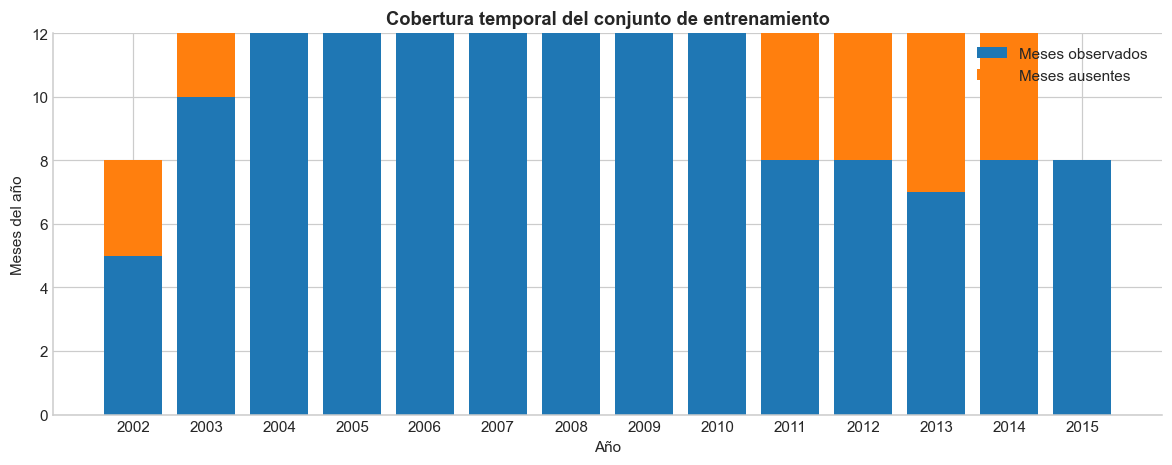

In [13]:
# Distribución de los meses ausentes por año.
ausentes_por_anio = pd.Series(meses_ausentes.year).value_counts().sort_index()
observados_por_anio = pd.Series(meses_observados.year).value_counts().sort_index()
cobertura_anual = pd.DataFrame({
    "meses_observados": observados_por_anio,
    "meses_ausentes": ausentes_por_anio,
}).fillna(0).astype(int)
cobertura_anual["cobertura_%"] = (
    cobertura_anual["meses_observados"]
    / (cobertura_anual["meses_observados"] + cobertura_anual["meses_ausentes"]) * 100
).round(1)
display(cobertura_anual)

fig, ax = plt.subplots(figsize=(13, 4.5))
ax.bar(cobertura_anual.index.astype(str), cobertura_anual["meses_observados"], label="Meses observados")
ax.bar(cobertura_anual.index.astype(str), cobertura_anual["meses_ausentes"],
       bottom=cobertura_anual["meses_observados"], label="Meses ausentes")
ax.set(title="Cobertura temporal del conjunto de entrenamiento",
       xlabel="Año", ylabel="Meses del año")
ax.legend()
guardar_figura("10_cobertura_temporal")
plt.show()

Celdas de la rejilla                  : 15,715
Filas si toda celda tuviera todo mes  : 2,168,670
Filas observadas                      : 2,154,021
Combinaciones ausentes                : 14,649 (0.68%)

Celdas con la serie completa          : 14,558 (92.6%)
Mínimo de meses en una celda          : 11


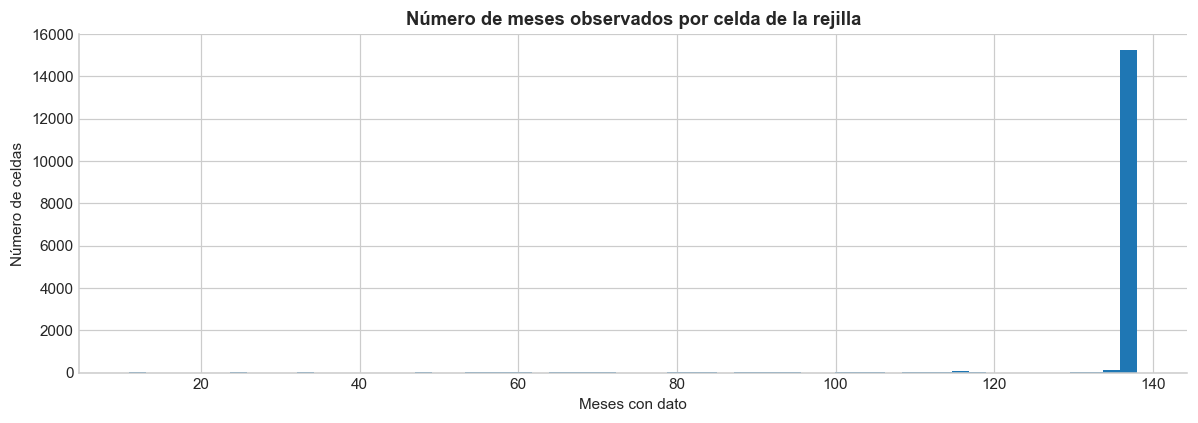

In [14]:
# Faltantes estructurales en el espacio: celdas sin la serie completa.
meses_por_celda = train.groupby([COL_LAT, COL_LON], observed=True).size()
n_celdas = len(meses_por_celda)
n_meses = len(meses_observados)

print(f"Celdas de la rejilla                  : {n_celdas:,}")
print(f"Filas si toda celda tuviera todo mes  : {n_celdas * n_meses:,}")
print(f"Filas observadas                      : {len(train):,}")
print(f"Combinaciones ausentes                : {n_celdas * n_meses - len(train):,} "
      f"({(1 - len(train)/(n_celdas*n_meses))*100:.2f}%)")
print(f"\nCeldas con la serie completa          : {(meses_por_celda == n_meses).sum():,} "
      f"({(meses_por_celda == n_meses).mean()*100:.1f}%)")
print(f"Mínimo de meses en una celda          : {meses_por_celda.min()}")

fig, ax = plt.subplots(figsize=(13, 4))
ax.hist(meses_por_celda.values, bins=60)
ax.set(title="Número de meses observados por celda de la rejilla",
       xlabel="Meses con dato", ylabel="Número de celdas")
guardar_figura("10_meses_por_celda")
plt.show()

In [15]:
# El conjunto de prueba tiene su propio patrón de cobertura, que conviene contrastar.
meses_test = pd.DatetimeIndex(sorted(test[COL_FECHA].unique()))
calendario_test = pd.date_range(meses_test.min(), meses_test.max(), freq="MS")

print(f"Rango del conjunto de prueba : {meses_test.min().date()} a {meses_test.max().date()}")
print(f"Meses del calendario         : {len(calendario_test)}")
print(f"Meses presentes en test      : {len(meses_test)}")
print("Meses presentes:", ", ".join(d.strftime("%Y-%m") for d in meses_test))

# Enmascaramiento deliberado de TWS_t en el conjunto de prueba.
col_mascara = next((c for c in test.columns if c.lower().endswith("_masked")), None)
if col_mascara is not None:
    print(f"\nFilas con {COL_TWS} enmascarado: {test[col_mascara].sum():,} "
          f"({test[col_mascara].mean()*100:.2f}%)")

Rango del conjunto de prueba : 2015-09-01 a 2018-12-01
Meses del calendario         : 40
Meses presentes en test      : 18
Meses presentes: 2015-09, 2016-01, 2016-02, 2016-03, 2016-06, 2016-07, 2016-08, 2016-09, 2016-12, 2017-01, 2017-02, 2017-03, 2017-04, 2017-05, 2017-06, 2018-07, 2018-11, 2018-12

Filas con TWS_t enmascarado: 186,913 (66.53%)


El enmascaramiento del conjunto de prueba **no es un defecto de los datos**. La
documentación oficial del reto explica que se introdujo a propósito para evitar
que el valor de `TWS_t` de una fila revele el objetivo oculto de otra fila de la
misma celda el mes anterior. Es una medida contra la fuga de información, y por
eso viene señalizado con su propia columna indicadora.

## 11. Limpieza y preprocesamiento

La limpieza es **conservadora**. Se corrigen tipos y se construyen variables
derivadas de la fecha, pero no se eliminan observaciones ni se imputan valores
sin justificación. En datos climáticos, un valor extremo puede ser exactamente el
evento que interesa detectar.

In [16]:
# Copia de trabajo: el DataFrame cargado del archivo original no se modifica.
df = train.copy()

# 1) Conversión de la fecha. El identificador tiene formato fecha_lat_lon,
#    por lo que la fecha puede reconstruirse desde ahí si hiciera falta.
if COL_FECHA is not None:
    df[COL_FECHA] = pd.to_datetime(df[COL_FECHA], errors="coerce")
elif COL_ID is not None:
    df["fecha"] = pd.to_datetime(df[COL_ID].str.split("_").str[0], format="%Y%m%d", errors="coerce")
    COL_FECHA = "fecha"

print(f"Columna de fecha: {COL_FECHA}")
print(f"Fechas no interpretables: {df[COL_FECHA].isna().sum():,}")
print(f"Rango temporal: {df[COL_FECHA].min().date()} a {df[COL_FECHA].max().date()}")
print(f"Meses únicos  : {df[COL_FECHA].nunique():,}")

Columna de fecha: time
Fechas no interpretables: 0
Rango temporal: 2002-05-01 a 2015-08-01
Meses únicos  : 138


In [17]:
# 2) Variables derivadas del tiempo. Se crean solo las que el análisis usa.
df["anio"] = df[COL_FECHA].dt.year
df["mes"] = df[COL_FECHA].dt.month
df["trimestre"] = df[COL_FECHA].dt.quarter

# 3) Hemisferio: el ciclo estacional es opuesto al norte y al sur del ecuador,
#    de modo que promediar el planeta entero puede cancelar la estacionalidad.
df["hemisferio"] = np.where(df[COL_LAT] >= 0, "Norte", "Sur")

# 4) Banda de latitud: variable categórica para comparar regiones climáticas.
cortes = [-90, -60, -35, -23.5, 0, 23.5, 35, 60, 90]
etiquetas = ["Polar sur", "Templada sur", "Subtropical sur", "Tropical sur",
             "Tropical norte", "Subtropical norte", "Templada norte", "Polar norte"]
df["banda_latitud"] = pd.cut(df[COL_LAT], bins=cortes, labels=etiquetas, include_lowest=True)

# 5) Orden cronológico, indispensable en una serie de tiempo.
df = df.sort_values([COL_FECHA] + [c for c in (COL_LAT, COL_LON) if c]).reset_index(drop=True)

display(df[[COL_FECHA, "anio", "mes", "trimestre", "hemisferio", "banda_latitud"]].head())

,time,anio,mes,trimestre,hemisferio,banda_latitud
0,2002-05-01,2002,5,2,Sur,Templada sur
1,2002-05-01,2002,5,2,Sur,Templada sur
2,2002-05-01,2002,5,2,Sur,Templada sur
3,2002-05-01,2002,5,2,Sur,Templada sur
4,2002-05-01,2002,5,2,Sur,Templada sur


In [18]:
# Resolución de la rejilla.
lats = np.sort(df[COL_LAT].unique())
lons = np.sort(df[COL_LON].unique())
paso_lat = np.diff(lats).min() if len(lats) > 1 else np.nan
paso_lon = np.diff(lons).min() if len(lons) > 1 else np.nan

print(f"Celdas únicas de la rejilla : {n_celdas:,}")
print(f"Latitudes únicas            : {len(lats):,}  (de {lats.min()} a {lats.max()})")
print(f"Longitudes únicas           : {len(lons):,}  (de {lons.min()} a {lons.max()})")
print(f"Paso en latitud             : {paso_lat}°")
print(f"Paso en longitud            : {paso_lon}°")

Celdas únicas de la rejilla : 15,715
Latitudes únicas            : 140  (de -55.5 a 83.5)
Longitudes únicas           : 358  (de -179.5 a 179.5)
Paso en latitud             : 1.0°
Paso en longitud            : 1.0°


### 11.1 Verificación de cómo se construyó la variable objetivo

La documentación indica que `target` es el almacenamiento del mes siguiente. Vale
la pena comprobarlo directamente en lugar de confiar en la descripción, porque de
ello depende toda la interpretación posterior: se compara, celda por celda, el
`target` de un mes contra el `TWS_t` del registro siguiente de esa misma celda.

In [19]:
# Para cada celda, se toma el siguiente registro disponible en el tiempo.
orden = df.sort_values([COL_LAT, COL_LON, COL_FECHA])
grupos = orden.groupby([COL_LAT, COL_LON], sort=False)
orden["tws_siguiente"] = grupos[COL_TWS].shift(-1)
orden["fecha_siguiente"] = grupos[COL_FECHA].shift(-1)

comparables = orden.dropna(subset=["tws_siguiente"])
coincide = np.isclose(comparables[COL_OBJETIVO], comparables["tws_siguiente"], atol=1e-5)

# Salto en meses entre un registro y el siguiente de la misma celda.
salto = ((comparables["fecha_siguiente"].dt.year - comparables[COL_FECHA].dt.year) * 12
         + (comparables["fecha_siguiente"].dt.month - comparables[COL_FECHA].dt.month))

print(f"Filas con registro siguiente en la misma celda: {len(comparables):,}")
print(f"En las que target coincide con ese TWS        : {coincide.sum():,} "
      f"({coincide.mean()*100:.2f}%)")

tabla_salto = pd.DataFrame({
    "filas": salto.value_counts().sort_index(),
    "coinciden": salto[coincide].value_counts().sort_index(),
}).fillna(0).astype(int).head(8)
tabla_salto.index.name = "salto en meses"
display(tabla_salto)

Filas con registro siguiente en la misma celda: 2,138,306
En las que target coincide con ese TWS        : 1,977,400 (92.48%)


,filas,coinciden
salto en meses,,
1,1977398,1977398
3,127211,1
4,31880,1
5,1093,0
6,322,0
7,150,0
8,71,0
9,78,0


La tabla anterior resuelve la pregunta con precisión. La coincidencia es
prácticamente total **cuando el salto al registro siguiente es de un mes**, y
desaparece cuando el salto es mayor. La conclusión es que `target` corresponde
siempre al mes calendario `t+1`, no «al siguiente mes disponible».

Esto tiene una consecuencia que conviene tener presente al modelar: para las
filas cuyo mes `t+1` es uno de los meses ausentes del archivo, el valor de
`target` es **la única información disponible sobre ese mes**. No es un dato
redundante, sino la observación de un mes que no aparece como fila propia.

## 12. Estadística descriptiva

Se resumen las variables cuantitativas y se complementa `describe()` con el rango
y el rango intercuartílico, que la función no reporta por defecto. La comparación
entre media y mediana es especialmente informativa: una diferencia grande indica
asimetría.

In [20]:
descriptivas = df[COLS_NUMERICAS].describe().T
descriptivas["mediana"] = df[COLS_NUMERICAS].median()
descriptivas["rango"] = descriptivas["max"] - descriptivas["min"]
descriptivas["IQR"] = descriptivas["75%"] - descriptivas["25%"]
descriptivas["asimetria"] = df[COLS_NUMERICAS].skew()
descriptivas = descriptivas[
    ["count", "mean", "mediana", "std", "min", "25%", "50%", "75%", "max", "rango", "IQR", "asimetria"]
]
display(descriptivas)

descriptivas.to_csv(TABLAS / "estadistica_descriptiva.csv")

,count,mean,mediana,std,min,25%,50%,75%,max,rango,IQR,asimetria
TWS_t,"2,154,021.0000",0.1170,0.1315,0.9130,-3.9683,-0.5267,0.1315,0.7858,4.0573,8.0256,1.3125,-0.0877
SPEI_01_t,"2,154,021.0000",-0.0304,-0.0559,0.9565,-4.2479,-0.7485,-0.0559,0.6661,3.4759,7.7238,1.4146,0.0881
SPEI_03_t,"2,154,021.0000",-0.0553,-0.0761,0.9444,-5.2253,-0.7611,-0.0761,0.6314,4.1773,9.4026,1.3925,0.0783
SPEI_06_t,"2,154,021.0000",-0.0706,-0.0894,0.9399,-4.3833,-0.7696,-0.0894,0.6098,4.8504,9.2337,1.3794,0.0753
SPEI_12_t,"2,154,021.0000",-0.0933,-0.1135,0.9307,-4.6224,-0.7793,-0.1135,0.5750,3.7647,8.3871,1.3543,0.0812
SOIL_MOISTURE_t,"2,154,021.0000",0.0008,0.0007,0.7875,-5.1072,-0.4452,0.0007,0.5027,5.3852,10.4924,0.9478,-0.1416
target,"2,154,021.0000",0.1125,0.1273,0.9120,-3.9683,-0.5294,0.1273,0.7807,4.0573,8.0256,1.3101,-0.0876


In [21]:
# Lectura automática de los rasgos principales, para no depender de la vista manual.
lineas = []
for col in COLS_NUMERICAS:
    media, mediana = df[col].mean(), df[col].median()
    sesgo = df[col].skew()
    forma = "simétrica" if abs(sesgo) < 0.5 else ("sesgada a la derecha" if sesgo > 0 else "sesgada a la izquierda")
    lineas.append(
        f"- **{col}**: media {media:,.3f}, mediana {mediana:,.3f}, "
        f"desviación {df[col].std():,.3f}, asimetría {sesgo:,.2f} → distribución {forma}."
    )

display(Markdown("**Resumen calculado sobre los datos:**\n\n" + "\n".join(lineas)))

**Resumen calculado sobre los datos:**

- **TWS_t**: media 0.117, mediana 0.132, desviación 0.913, asimetría -0.09 → distribución simétrica.
- **SPEI_01_t**: media -0.030, mediana -0.056, desviación 0.957, asimetría 0.09 → distribución simétrica.
- **SPEI_03_t**: media -0.055, mediana -0.076, desviación 0.944, asimetría 0.08 → distribución simétrica.
- **SPEI_06_t**: media -0.071, mediana -0.089, desviación 0.940, asimetría 0.08 → distribución simétrica.
- **SPEI_12_t**: media -0.093, mediana -0.113, desviación 0.931, asimetría 0.08 → distribución simétrica.
- **SOIL_MOISTURE_t**: media 0.001, mediana 0.001, desviación 0.787, asimetría -0.14 → distribución simétrica.
- **target**: media 0.113, mediana 0.127, desviación 0.912, asimetría -0.09 → distribución simétrica.

### 12.1 Lectura de los resultados

**Las variables están estandarizadas y son adimensionales.** Todas tienen media
cercana a cero y desviación cercana a uno: `TWS_t` presenta media 0.117 y
desviación 0.913, y `target` media 0.113 y desviación 0.912. Esto **no** son
centímetros de lámina de agua, que es la unidad habitual de los productos GRACE.
Es un dato importante y fácil de pasar por alto: los valores no pueden
interpretarse como volúmenes, solo como desviaciones relativas respecto a la
referencia con la que fueron estandarizados. Cualquier afirmación sobre "cuánta"
agua se perdió en términos físicos quedaría fuera de lo que estos datos permiten
sostener.

**Las distribuciones son casi simétricas.** Los coeficientes de asimetría son muy
pequeños en todas las variables (entre −0.14 y 0.09), y en cada una la media y la
mediana casi coinciden. Es el comportamiento esperable de índices estandarizados y
contrasta con lo que suele encontrarse en datos de conteo o de volumen, donde la
asimetría a la derecha es la norma.

**Los SPEI tienen media ligeramente negativa, y la desviación crece con la escala
de acumulación.** Las medias van de −0.030 en `SPEI_01_t` a −0.093 en `SPEI_12_t`:
cuanto más largo es el periodo acumulado, más negativo es el promedio. Es un
indicio de déficit hídrico sostenido en el conjunto del periodo, aunque de
magnitud modesta.

**`SOIL_MOISTURE_t` es la variable más concentrada y la de cola más larga.** Su
desviación es 0.788, claramente menor que la del resto, y su IQR de 0.948 es el
más estrecho; sin embargo, su rango total (10.49) es el más amplio de todas. Es
decir: la mayoría de las observaciones se agrupan en un intervalo angosto, pero
existen valores muy alejados. Esto anticipa lo que se verá en la sección 15.

## 13. Análisis de variables categóricas

El conjunto de datos es esencialmente numérico: no incluye columnas de texto ni
categorías nominales. Sin embargo, el análisis exploratorio sí requiere variables
categóricas, y en este problema hay tres que son sustantivas y no artificiales:

1. **Mes y hemisferio**, que estructuran el ciclo estacional.
2. **Banda de latitud**, que agrupa las celdas en regímenes climáticos.
3. **Categoría de sequía según el SPEI**, que es la clasificación estándar del
   propio indicador y convierte una variable continua en una escala ordinal
   interpretable.

Para cada una se calculan tablas de frecuencia y de proporciones, y gráficos de
barras, tal como exige la rúbrica.

,frecuencia,proporción_%
banda_latitud,,
Polar sur,0,0.0000
Templada sur,38188,1.7700
Subtropical sur,118237,5.4900
Tropical sur,267636,12.4200
Tropical norte,307545,14.2800
Subtropical norte,223897,10.3900
Templada norte,662020,30.7300
Polar norte,536498,24.9100


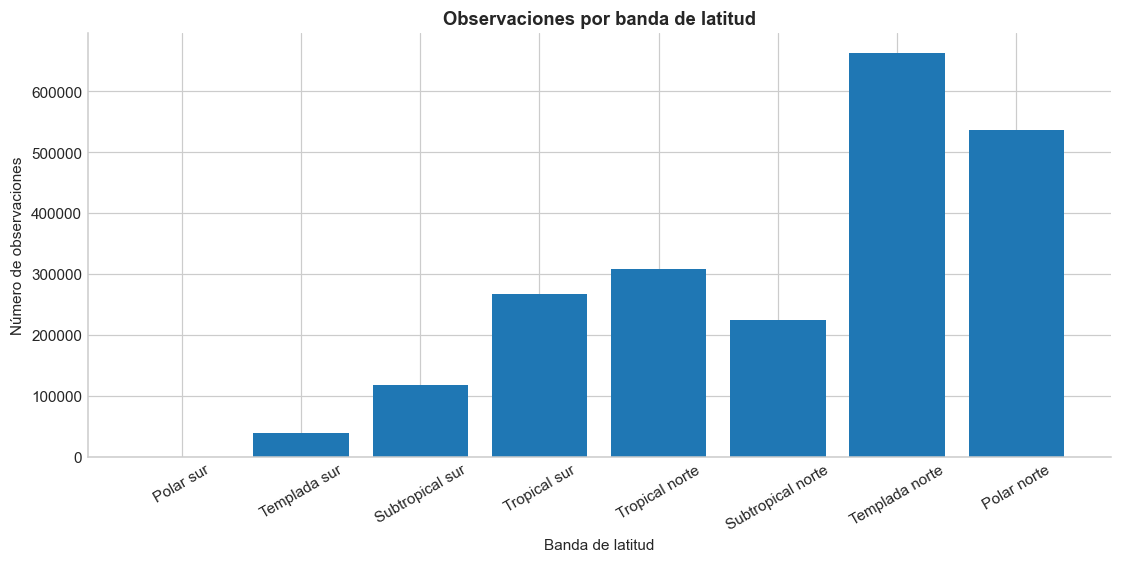

In [22]:
# Frecuencias y proporciones por banda de latitud.
frec_banda = df["banda_latitud"].value_counts().sort_index()
prop_banda = df["banda_latitud"].value_counts(normalize=True).sort_index() * 100
tabla_banda = pd.DataFrame({"frecuencia": frec_banda, "proporción_%": prop_banda.round(2)})
display(tabla_banda)

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(tabla_banda.index.astype(str), tabla_banda["frecuencia"])
ax.set(title="Observaciones por banda de latitud",
       xlabel="Banda de latitud", ylabel="Número de observaciones")
ax.tick_params(axis="x", rotation=30)
guardar_figura("13_frecuencia_banda_latitud")
plt.show()

,frecuencia,proporción_%
hemisferio,,
Norte,1729960,80.3100
Sur,424061,19.6900


,frecuencia,proporción_%
anio,,
2002,77842,3.6100
2003,156255,7.2500
2004,187341,8.7000
2005,187306,8.7000
2006,187323,8.7000
2007,187380,8.7000
2008,187355,8.7000
2009,187262,8.6900
2010,187133,8.6900


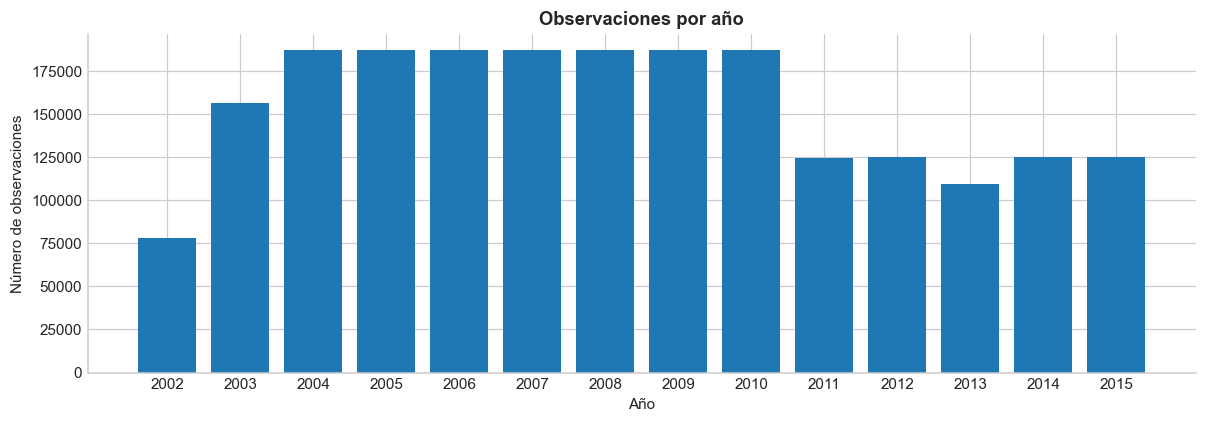

In [23]:
# Frecuencias y proporciones por hemisferio.
tabla_hemisferio = pd.DataFrame({
    "frecuencia": df["hemisferio"].value_counts(),
    "proporción_%": (df["hemisferio"].value_counts(normalize=True) * 100).round(2),
})
display(tabla_hemisferio)

# Observaciones por año: verifica si la cobertura temporal es homogénea.
tabla_anio = pd.DataFrame({
    "frecuencia": df["anio"].value_counts().sort_index(),
    "proporción_%": (df["anio"].value_counts(normalize=True).sort_index() * 100).round(2),
})
display(tabla_anio)

fig, ax = plt.subplots(figsize=(13, 4))
ax.bar(tabla_anio.index.astype(str), tabla_anio["frecuencia"])
ax.set(title="Observaciones por año", xlabel="Año", ylabel="Número de observaciones")
guardar_figura("13_frecuencia_por_anio")
plt.show()

,frecuencia,proporción_%
categoria_sequia,,
Sequía extrema,18812,0.8700
Sequía severa,104149,4.8400
Sequía moderada,248704,11.5500
Normal,1439913,66.8500
Húmedo moderado,209833,9.7400
Húmedo severo,106623,4.9500
Húmedo extremo,25987,1.2100
Sin dato,0,0.0000


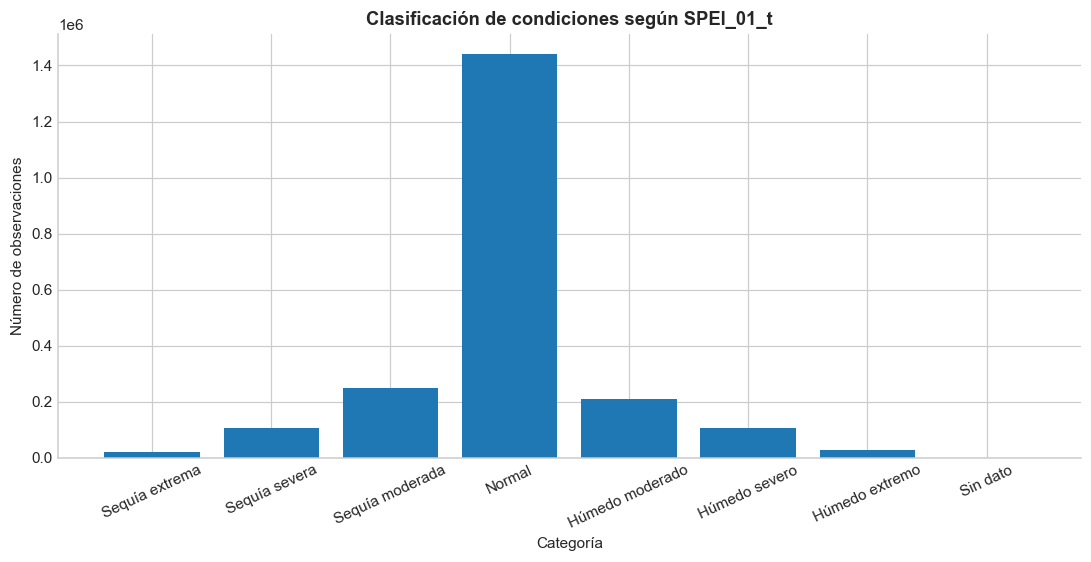

In [24]:
# Categoría de sequía según la escala estándar del SPEI.
# Referencia: Vicente-Serrano et al., https://spei.csic.es
def categoria_spei(valor):
    if pd.isna(valor):
        return "Sin dato"
    if valor <= -2.0:
        return "Sequía extrema"
    if valor <= -1.5:
        return "Sequía severa"
    if valor <= -1.0:
        return "Sequía moderada"
    if valor < 1.0:
        return "Normal"
    if valor < 1.5:
        return "Húmedo moderado"
    if valor < 2.0:
        return "Húmedo severo"
    return "Húmedo extremo"


orden_categorias = ["Sequía extrema", "Sequía severa", "Sequía moderada", "Normal",
                    "Húmedo moderado", "Húmedo severo", "Húmedo extremo", "Sin dato"]

if COLS_SPEI:
    col_spei_ref = COLS_SPEI[0]
    df["categoria_sequia"] = df[col_spei_ref].map(categoria_spei)
    df["categoria_sequia"] = pd.Categorical(df["categoria_sequia"], categories=orden_categorias, ordered=True)

    tabla_sequia = pd.DataFrame({
        "frecuencia": df["categoria_sequia"].value_counts().reindex(orden_categorias),
        "proporción_%": (df["categoria_sequia"].value_counts(normalize=True).reindex(orden_categorias) * 100).round(2),
    }).dropna(how="all")
    display(tabla_sequia)

    fig, ax = plt.subplots(figsize=(12, 5))
    ax.bar(tabla_sequia.index.astype(str), tabla_sequia["frecuencia"])
    ax.set(title=f"Clasificación de condiciones según {col_spei_ref}",
           xlabel="Categoría", ylabel="Número de observaciones")
    ax.tick_params(axis="x", rotation=25)
    guardar_figura("13_categorias_sequia_spei")
    plt.show()

### 13.1 Lectura de las variables categóricas

**El conjunto está fuertemente desbalanceado en el espacio.** El hemisferio norte
concentra el 80.3 % de las observaciones frente a un 19.7 % del sur, y dos bandas
—templada norte (30.7 %) y polar norte (24.9 %)— reúnen por sí solas más de la
mitad del total. La banda polar sur **no tiene ninguna observación**. Esto no es un
error de los datos: refleja la distribución real de tierra emergida en el planeta y
el hecho de que la Antártida queda fuera de la cobertura, algo coherente con el
rango de latitudes observado, que llega hasta −55.5° por el sur y hasta 83.5° por
el norte. La consecuencia práctica es que **cualquier promedio "global" de este
conjunto está dominado por el hemisferio norte**, y así debe interpretarse.

**La cobertura por año tampoco es uniforme.** Los años 2004 a 2010 aportan cada
uno alrededor del 8.7 % de las observaciones, mientras que 2011 a 2015 aportan
entre 5.1 % y 5.8 %, y 2002 solo 3.6 %. Esta caída se explica por los meses
ausentes que se documentaron en la sección 10, no por una pérdida de celdas.

**Según el SPEI a un mes, cerca de una de cada seis observaciones corresponde a
condiciones de sequía.** El 66.9 % se clasifica como normal, mientras que las tres
categorías de sequía suman 17.3 % (11.6 % moderada, 4.8 % severa y 0.9 % extrema) y
las tres húmedas suman 15.8 %. La distribución es aproximadamente simétrica en
torno a la categoría normal, lo que es consistente con que el SPEI sea un índice
estandarizado por construcción.

## 14. Distribuciones

Se examina la forma de cada variable numérica: dónde se concentra, qué tan
dispersa está, si es simétrica y si hay indicios de más de una población.

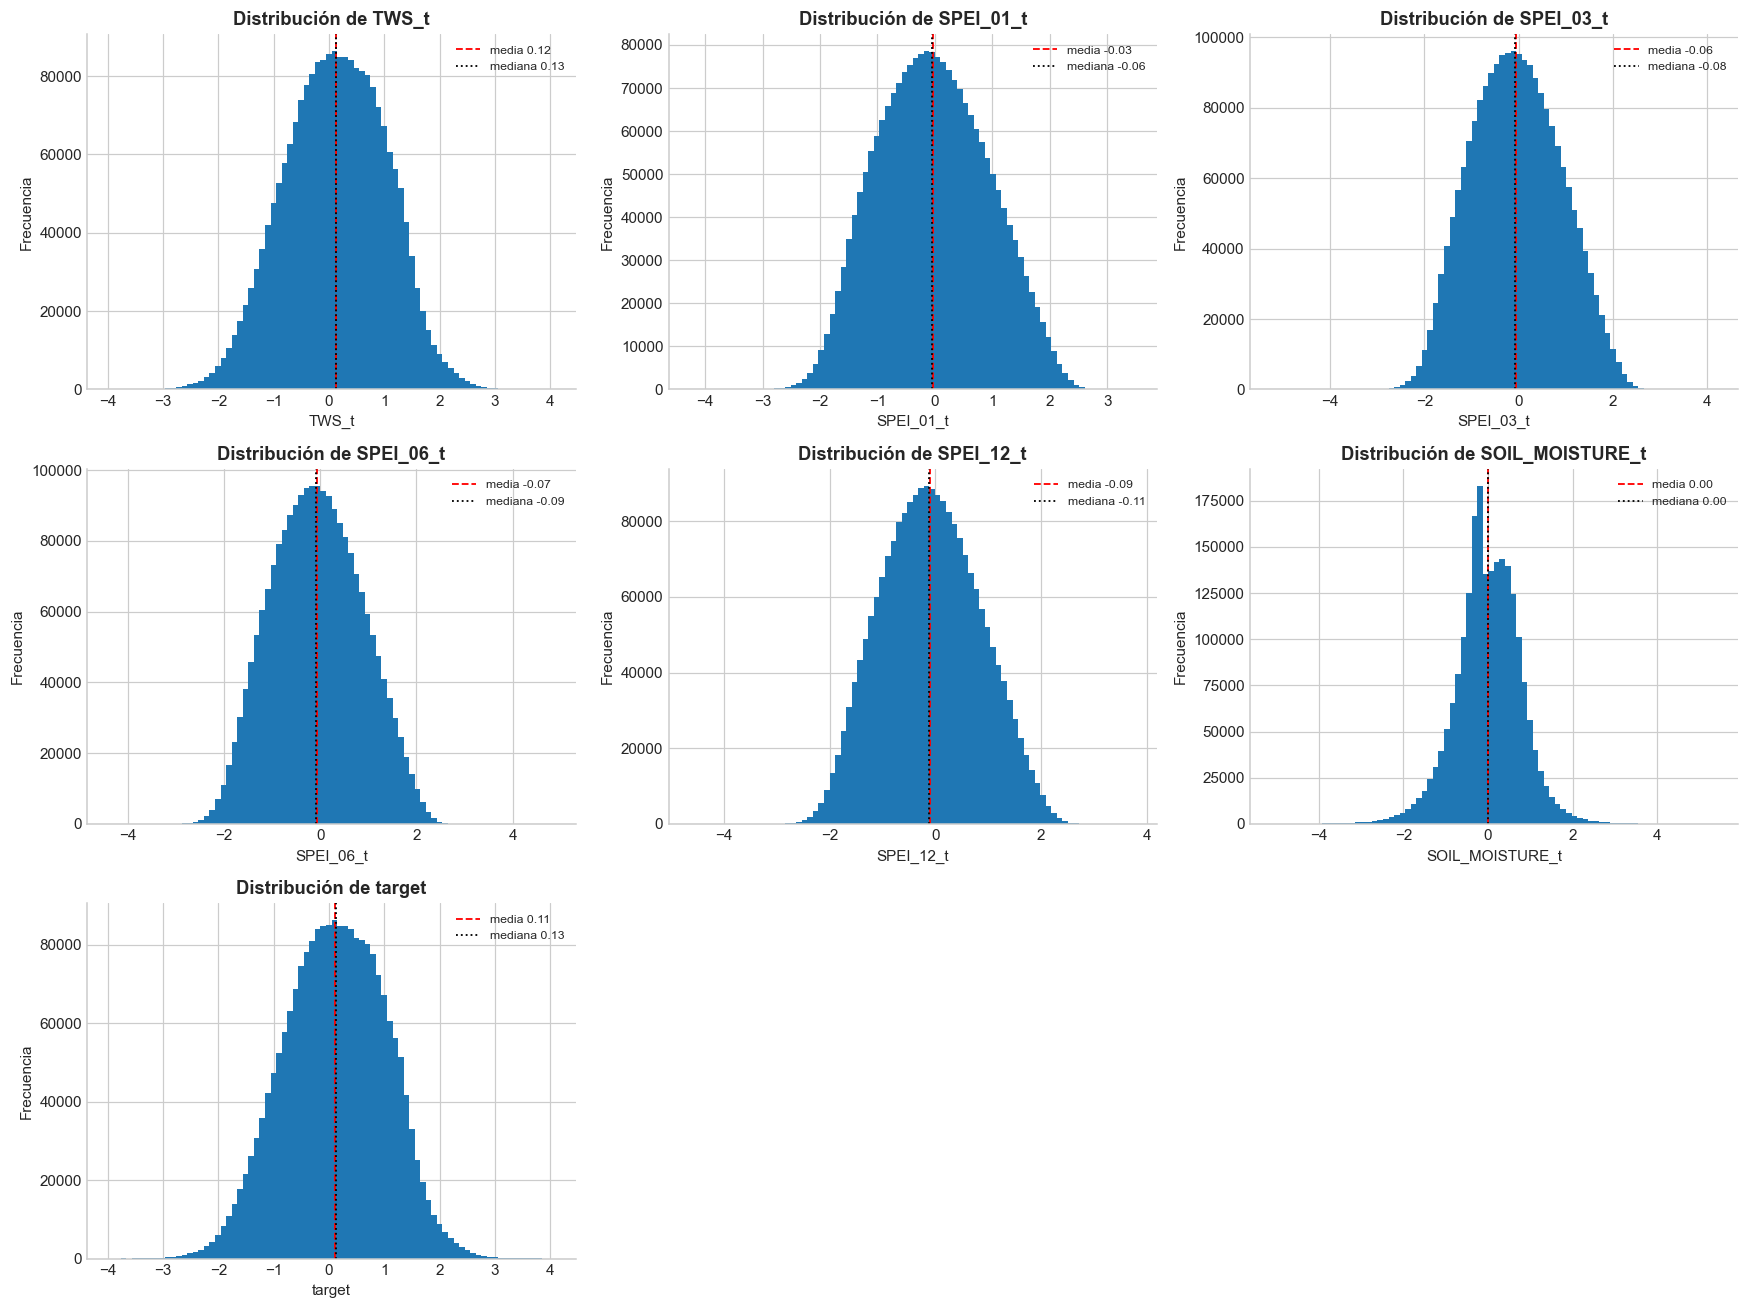

In [25]:
n = len(COLS_NUMERICAS)
filas = int(np.ceil(n / 3))
fig, axes = plt.subplots(filas, 3, figsize=(16, 4 * filas))
axes = np.atleast_1d(axes).ravel()

for ax, col in zip(axes, COLS_NUMERICAS):
    datos = df[col].dropna()
    ax.hist(datos, bins=80)
    ax.axvline(datos.mean(), color="red", linestyle="--", linewidth=1.2, label=f"media {datos.mean():.2f}")
    ax.axvline(datos.median(), color="black", linestyle=":", linewidth=1.2, label=f"mediana {datos.median():.2f}")
    ax.set(title=f"Distribución de {col}", xlabel=col, ylabel="Frecuencia")
    ax.legend(fontsize=8)

for ax in axes[n:]:
    ax.axis("off")

plt.tight_layout()
guardar_figura("14_histogramas_variables")
plt.show()

### 14.1 Lectura de los histogramas

Los seis histogramas muestran distribuciones **unimodales y aproximadamente
simétricas**, sin indicios de mezcla de poblaciones: en ninguna aparece un segundo
máximo que sugiera dos regímenes distintos superpuestos. En todas las variables la
línea de la media y la de la mediana quedan prácticamente encima una de la otra,
lo que confirma numéricamente lo que la forma sugiere.

`TWS_t` y `target` tienen histogramas casi indistinguibles entre sí, algo esperable
si una es la otra desplazada un mes: comparten mínimo (−3.968) y máximo (4.057).

La diferencia más marcada la presenta `SOIL_MOISTURE_t`, con un pico central mucho
más alto y estrecho que el resto y colas visiblemente más largas. Es la firma de una
variable donde la enorme mayoría de las observaciones está cerca de lo normal y unas
pocas se apartan mucho, y explica por qué será la variable con más atípicos.

## 15. Detección y análisis de valores atípicos

Se identifican los valores extremos con el criterio del rango intercuartílico
(IQR), el mismo utilizado en los laboratorios del curso: se marca como atípico
todo valor fuera del intervalo $[Q_1 - 1.5\,IQR,\; Q_3 + 1.5\,IQR]$.

**Criterio adoptado: no se elimina ningún valor atípico.** En una variable que
mide anomalías de almacenamiento de agua, los valores extremos son precisamente
las sequías e inundaciones severas, es decir, el fenómeno que el modelo debe
aprender a anticipar. Eliminarlos destruiría la señal de interés. Los atípicos se
cuantifican, se localizan en el tiempo y en el espacio, y se documentan.

In [26]:
resumen_atipicos = []
for col in COLS_NUMERICAS:
    q1, q3 = df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    inferior, superior = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    marca = (df[col] < inferior) | (df[col] > superior)
    resumen_atipicos.append({
        "variable": col,
        "Q1": q1, "Q3": q3, "IQR": iqr,
        "límite_inferior": inferior, "límite_superior": superior,
        "n_atípicos": int(marca.sum()),
        "%_atípicos": round(marca.mean() * 100, 2),
    })

tabla_atipicos = pd.DataFrame(resumen_atipicos).set_index("variable")
display(tabla_atipicos)
tabla_atipicos.to_csv(TABLAS / "outliers_iqr.csv")

,Q1,Q3,IQR,límite_inferior,límite_superior,n_atípicos,%_atípicos
variable,,,,,,,
TWS_t,-0.5267,0.7858,1.3125,-2.4955,2.7546,5343,0.2500
SPEI_01_t,-0.7485,0.6661,1.4146,-2.8704,2.7880,687,0.0300
SPEI_03_t,-0.7611,0.6314,1.3925,-2.8499,2.7201,552,0.0300
SPEI_06_t,-0.7696,0.6098,1.3794,-2.8386,2.6789,537,0.0200
SPEI_12_t,-0.7793,0.5750,1.3543,-2.8108,2.6064,727,0.0300
SOIL_MOISTURE_t,-0.4452,0.5027,0.9478,-1.8669,1.9244,55481,2.5800
target,-0.5294,0.7807,1.3101,-2.4947,2.7459,5427,0.2500


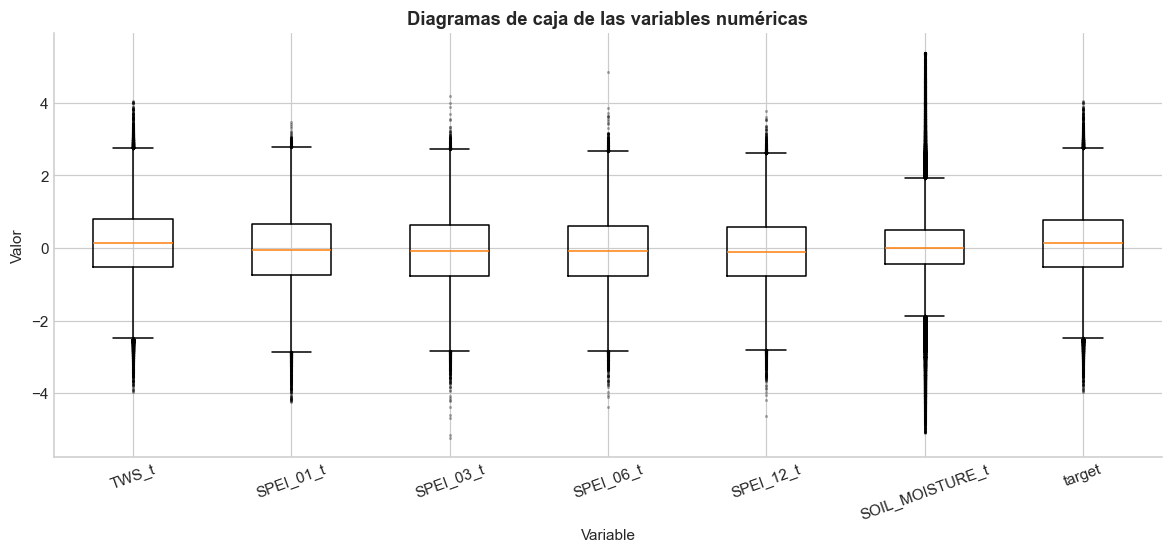

In [27]:
fig, ax = plt.subplots(figsize=(13, 5))
datos_box = [df[c].dropna().values for c in COLS_NUMERICAS]
ax.boxplot(datos_box, tick_labels=COLS_NUMERICAS, showfliers=True, flierprops={"markersize": 1, "alpha": 0.3})
ax.set(title="Diagramas de caja de las variables numéricas",
       xlabel="Variable", ylabel="Valor")
ax.tick_params(axis="x", rotation=20)
guardar_figura("15_boxplots_variables")
plt.show()

Observaciones atípicas en target: 5,427 (0.25%)


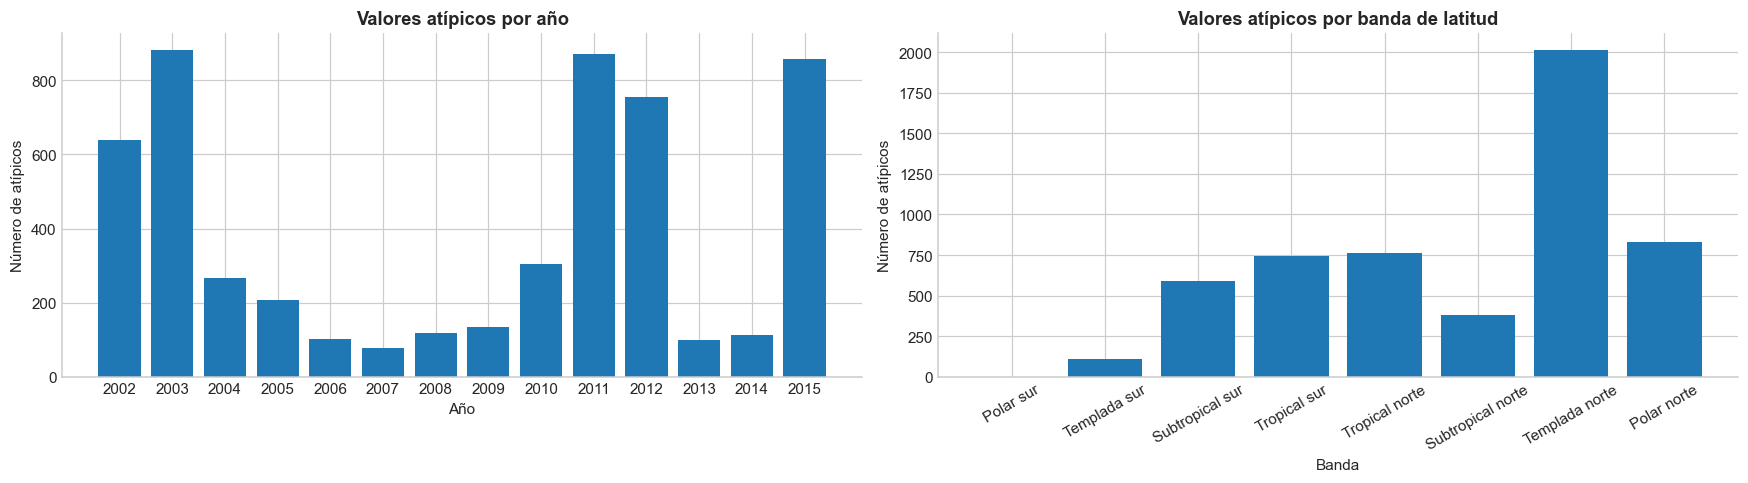

In [28]:
# ¿Los valores extremos de la variable objetivo se concentran en algún periodo o región?
q1, q3 = df[COL_OBJETIVO].quantile([0.25, 0.75])
iqr = q3 - q1
extremos = df[(df[COL_OBJETIVO] < q1 - 1.5 * iqr) | (df[COL_OBJETIVO] > q3 + 1.5 * iqr)]

print(f"Observaciones atípicas en {COL_OBJETIVO}: {len(extremos):,} ({len(extremos)/len(df)*100:.2f}%)")

fig, axes = plt.subplots(1, 2, figsize=(16, 4.5))
por_anio = extremos["anio"].value_counts().sort_index()
axes[0].bar(por_anio.index.astype(str), por_anio.values)
axes[0].set(title="Valores atípicos por año", xlabel="Año", ylabel="Número de atípicos")

por_banda = extremos["banda_latitud"].value_counts().sort_index()
axes[1].bar(por_banda.index.astype(str), por_banda.values)
axes[1].set(title="Valores atípicos por banda de latitud", xlabel="Banda", ylabel="Número de atípicos")
axes[1].tick_params(axis="x", rotation=30)
plt.tight_layout()
guardar_figura("15_atipicos_tiempo_espacio")
plt.show()

### 15.1 Lectura de los valores atípicos

**La proporción de atípicos es muy baja en casi todas las variables.** Con el
criterio del IQR, `target` y `TWS_t` marcan un 0.25 % de las observaciones y los
cuatro SPEI apenas entre 0.02 % y 0.03 %. La excepción clara es
`SOIL_MOISTURE_t` con **2.58 %**, diez veces más que la variable objetivo, lo cual
concuerda con la forma de su histograma: al ser una distribución muy concentrada,
el IQR resulta estrecho y el criterio marca como extremo un conjunto de valores
más amplio.

Esto ilustra una limitación del método que conviene explicitar: **la regla del IQR
mide qué tan lejos está un valor del grueso de la distribución, no si el valor es
erróneo**. En una variable muy concentrada marca más observaciones sin que ello
implique más errores.

**Decisión: no se elimina ningún valor atípico.** Las razones son concretas y se
apoyan en lo observado:

- Los valores extremos de `target` alcanzan −3.97 y 4.06, magnitudes plausibles
  para anomalías estandarizadas de almacenamiento; no hay valores imposibles, ni
  saltos de escala, ni códigos centinela del tipo −9999.
- Los gráficos de esta sección muestran que los atípicos **no se distribuyen al
  azar**: se concentran en determinados años y bandas de latitud. Ese
  agrupamiento es la firma de eventos hidrológicos reales —sequías e
  inundaciones prolongadas— y no de errores de medición, que no tendrían por qué
  agruparse así.
- Son precisamente los eventos extremos los que el reto busca anticipar.
  Eliminarlos equivaldría a borrar el fenómeno de interés.

## 16. Análisis temporal

Esta es la sección central del análisis, por tratarse de un problema de series de
tiempo. Se construye una serie mensual agregando todas las celdas de la rejilla y
se estudia su tendencia, su variabilidad y sus periodos anómalos, siguiendo el
procedimiento del ejemplo de series de tiempo visto en clase.

Una advertencia metodológica: promediar el planeta completo mezcla el hemisferio
norte y el sur, cuyos ciclos estacionales están desfasados seis meses. Por eso,
además de la serie global, se construyen series por hemisferio.

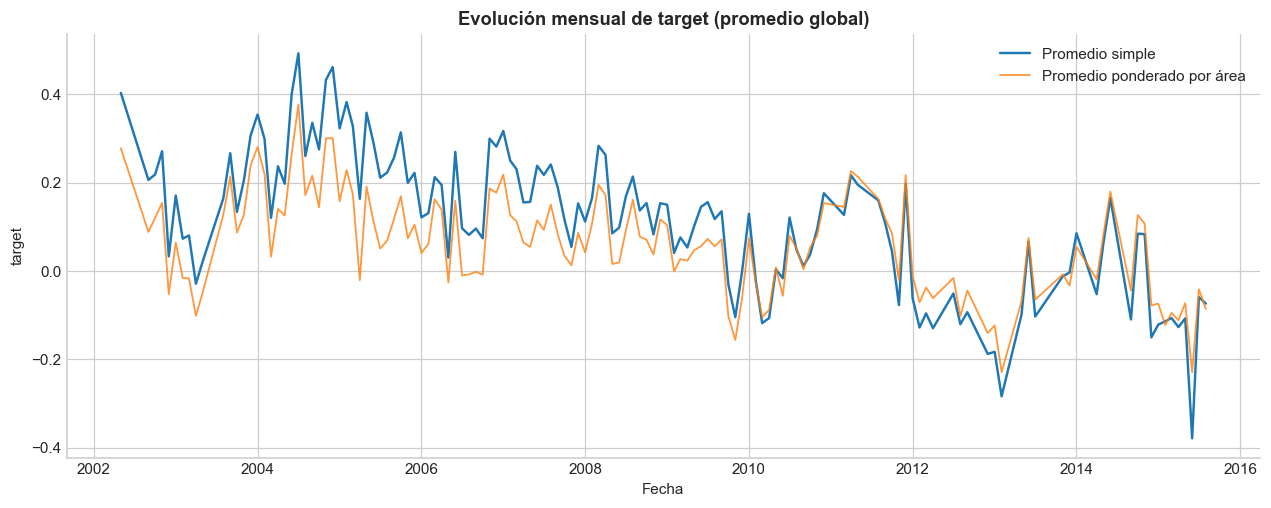

Correlación entre ambas agregaciones: 0.9360


In [29]:
# Serie mensual global. Se compara el promedio simple con el promedio ponderado
# por el coseno de la latitud, que corrige el hecho de que las celdas cercanas a
# los polos representan menos área que las cercanas al ecuador.
serie_global = df.groupby(COL_FECHA)[COL_OBJETIVO].mean()

peso = np.cos(np.deg2rad(df[COL_LAT]))
serie_ponderada = (
    df.assign(_num=df[COL_OBJETIVO] * peso, _den=peso.where(df[COL_OBJETIVO].notna()))
      .groupby(COL_FECHA)[["_num", "_den"]].sum()
      .pipe(lambda t: t["_num"] / t["_den"])
)

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(serie_global.index, serie_global.values, label="Promedio simple", linewidth=1.6)
ax.plot(serie_ponderada.index, serie_ponderada.values, label="Promedio ponderado por área", linewidth=1.2, alpha=0.8)
ax.set(title=f"Evolución mensual de {COL_OBJETIVO} (promedio global)",
       xlabel="Fecha", ylabel=COL_OBJETIVO)
ax.legend()
guardar_figura("16_serie_global")
plt.show()

print(f"Correlación entre ambas agregaciones: {serie_global.corr(serie_ponderada):.4f}")

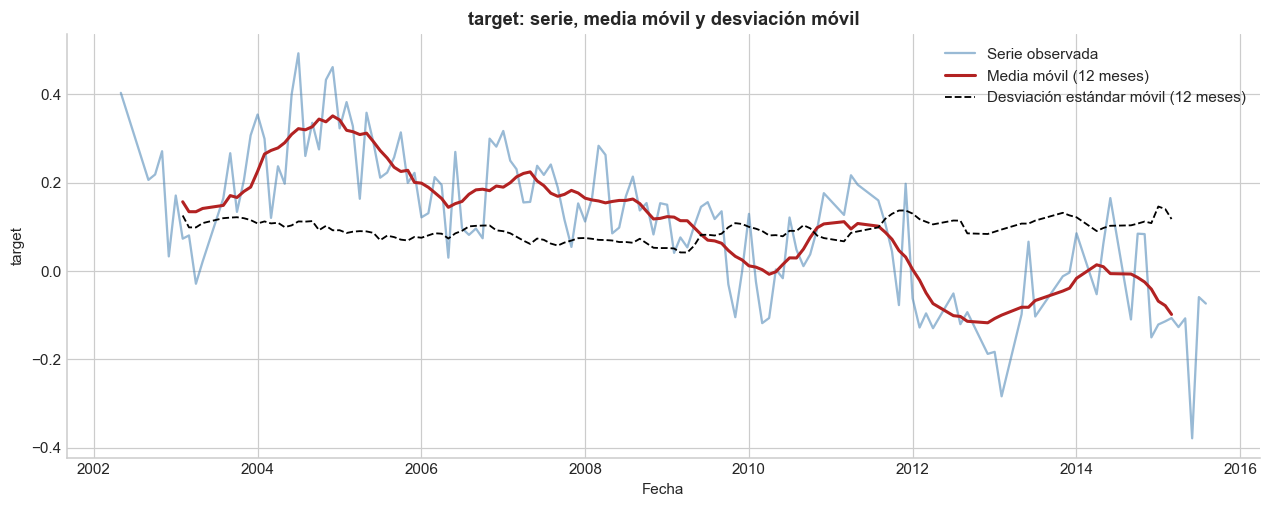

In [30]:
# Media y desviación móviles de 12 meses. La ventana es de 12 porque los datos
# son mensuales y el ciclo dominante esperado es anual: así la media móvil
# elimina la estacionalidad y deja ver la tendencia.
media_movil = serie_global.rolling(window=12, center=True).mean()
desv_movil = serie_global.rolling(window=12, center=True).std()

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(serie_global.index, serie_global.values, color="steelblue", alpha=0.55, label="Serie observada")
ax.plot(media_movil.index, media_movil.values, color="firebrick", linewidth=2, label="Media móvil (12 meses)")
ax.plot(desv_movil.index, desv_movil.values, color="black", linewidth=1.2, linestyle="--",
        label="Desviación estándar móvil (12 meses)")
ax.set(title=f"{COL_OBJETIVO}: serie, media móvil y desviación móvil",
       xlabel="Fecha", ylabel=COL_OBJETIVO)
ax.legend()
guardar_figura("16_media_movil")
plt.show()

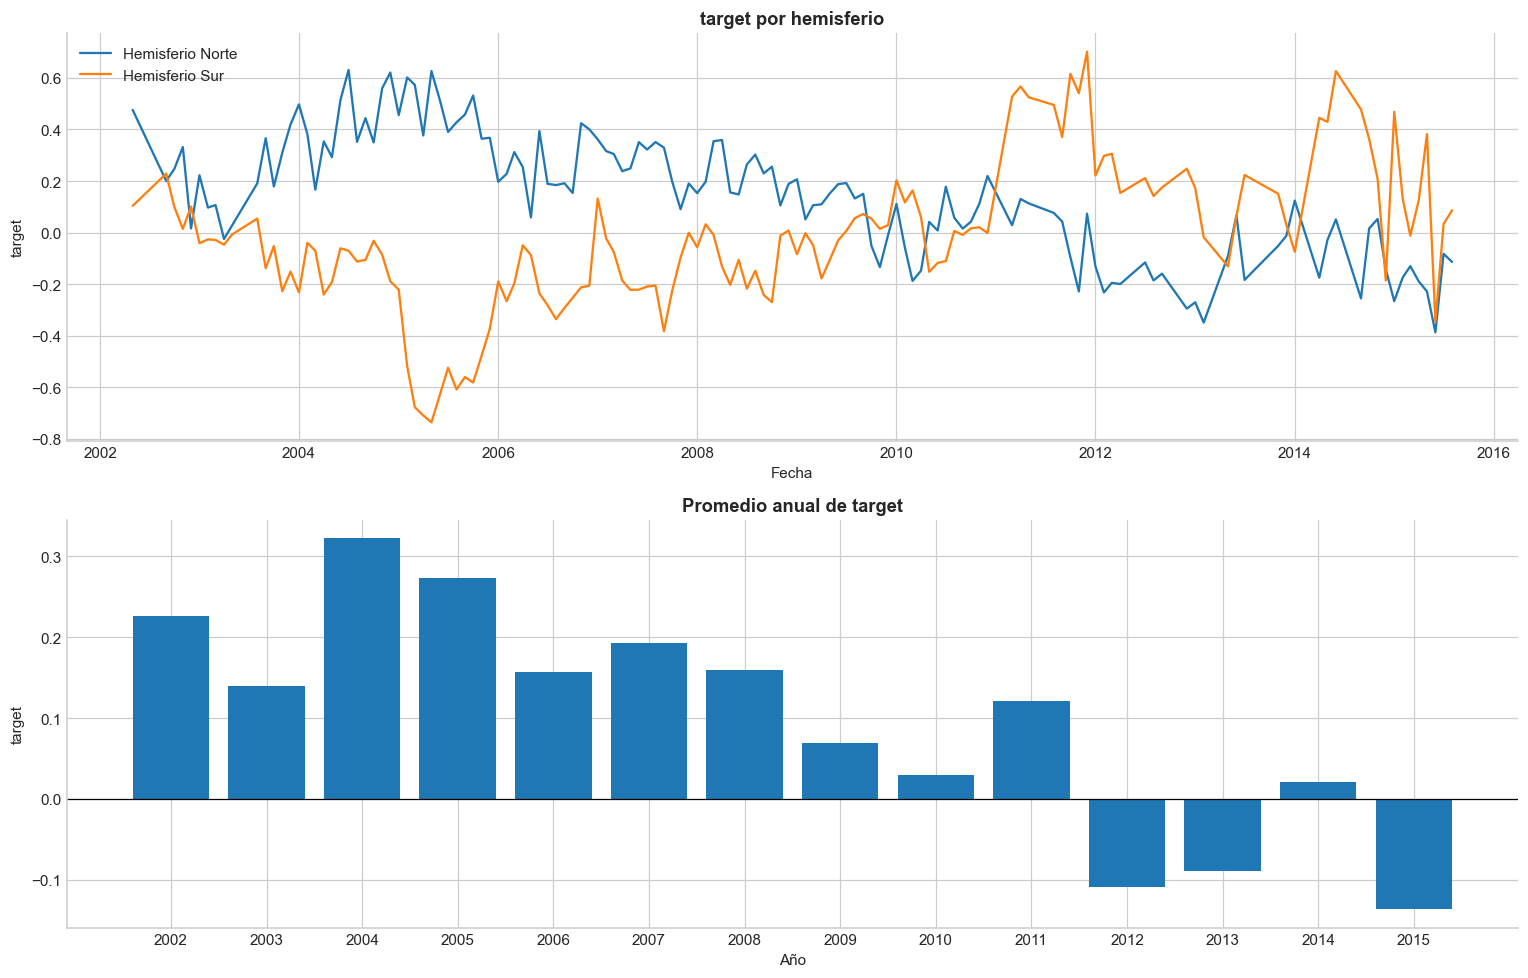

,promedio_anual
anio,
2002,0.2262
2003,0.1392
2004,0.3219
2005,0.2725
2006,0.1573
2007,0.1930
2008,0.1596
2009,0.0696
2010,0.0295


In [31]:
# Series por hemisferio y promedio anual.
serie_hemisferio = df.pivot_table(index=COL_FECHA, columns="hemisferio", values=COL_OBJETIVO, aggfunc="mean")

fig, axes = plt.subplots(2, 1, figsize=(14, 9))
for columna in serie_hemisferio.columns:
    axes[0].plot(serie_hemisferio.index, serie_hemisferio[columna], label=f"Hemisferio {columna}")
axes[0].set(title=f"{COL_OBJETIVO} por hemisferio", xlabel="Fecha", ylabel=COL_OBJETIVO)
axes[0].legend()

promedio_anual = df.groupby("anio")[COL_OBJETIVO].mean()
axes[1].bar(promedio_anual.index.astype(str), promedio_anual.values)
axes[1].axhline(0, color="black", linewidth=0.8)
axes[1].set(title=f"Promedio anual de {COL_OBJETIVO}", xlabel="Año", ylabel=COL_OBJETIVO)

plt.tight_layout()
guardar_figura("16_hemisferios_y_anual")
plt.show()

display(promedio_anual.to_frame("promedio_anual"))

### 16.1 Lectura del comportamiento temporal

**Existe una tendencia descendente clara.** El promedio anual de `target` pasa de
0.322 en 2004 —su valor más alto— a −0.136 en 2015, con caída sostenida desde
2008. Los últimos cuatro años del periodo (2012, 2013 y 2015) son los únicos con
promedio negativo. En términos del propio conjunto, esto significa que hacia el
final del registro el almacenamiento de agua está sistemáticamente por debajo de
la referencia con la que se estandarizaron los datos.

**La agregación elegida no altera esa conclusión.** El promedio simple y el
promedio ponderado por el coseno de la latitud —que corrige el hecho de que las
celdas polares cubren mucho menos área que las ecuatoriales— tienen una
correlación de **0.936**. Las dos curvas describen el mismo movimiento de fondo,
de modo que la tendencia observada no es un artefacto de dar demasiado peso a las
latitudes altas.

**La media móvil de 12 meses confirma la tendencia y suaviza el ruido.** Se eligió
una ventana de 12 porque los datos son mensuales y el ciclo esperado es anual: con
ese ancho, la media móvil promedia exactamente un ciclo completo y por lo tanto
cancela la estacionalidad, dejando a la vista el movimiento de largo plazo.

**Los dos hemisferios no se comportan igual.** La serie del hemisferio norte se
mantiene por encima de la del sur durante prácticamente todo el periodo. Este
contraste es el que motiva separar el análisis estacional de la sección siguiente.

## 17. Estacionalidad

Se investiga si la variable objetivo presenta un ciclo anual. Se usan tres
herramientas complementarias: el perfil mensual promedio, los diagramas de caja
por mes y la descomposición de la serie, esta última con la misma función
`seasonal_decompose` empleada en el ejemplo de clase.

En una descomposición aditiva la serie se separa en tres componentes:

- **Tendencia**: el movimiento de fondo, de largo plazo.
- **Estacionalidad**: el patrón que se repite con periodo fijo, aquí de 12 meses.
- **Residuo**: lo que no explican las dos anteriores; ahí quedan los eventos
  anómalos.

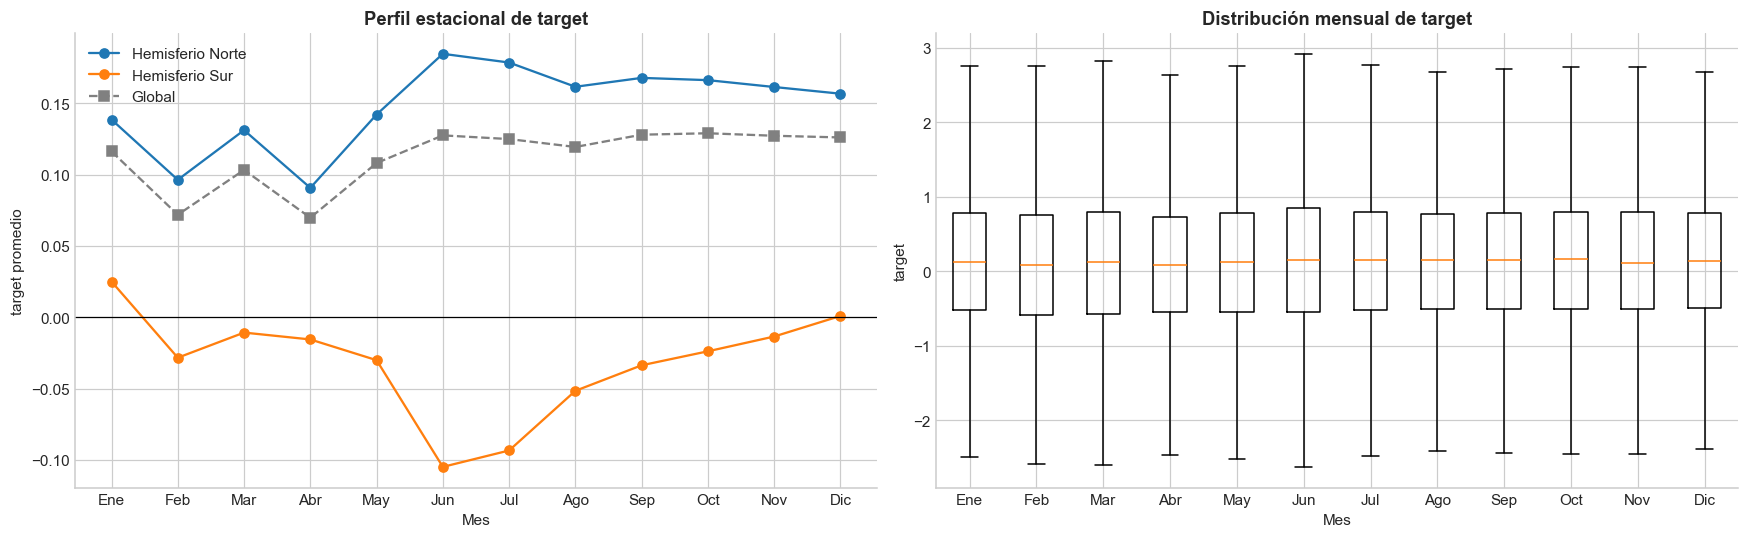

hemisferio,Norte,Sur
mes,,
1,0.1387,0.0250
2,0.0964,-0.0284
3,0.1312,-0.0107
4,0.0908,-0.0155
5,0.1422,-0.0301
6,0.1848,-0.1049
7,0.1786,-0.0934
8,0.1616,-0.0516
9,0.1679,-0.0337


In [32]:
nombres_mes = ["Ene", "Feb", "Mar", "Abr", "May", "Jun",
               "Jul", "Ago", "Sep", "Oct", "Nov", "Dic"]

perfil_mensual = df.groupby(["hemisferio", "mes"])[COL_OBJETIVO].mean().unstack("hemisferio")

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
for columna in perfil_mensual.columns:
    axes[0].plot(perfil_mensual.index, perfil_mensual[columna], marker="o", label=f"Hemisferio {columna}")
axes[0].plot(df.groupby("mes")[COL_OBJETIVO].mean(), marker="s", linestyle="--", color="gray", label="Global")
axes[0].set(title=f"Perfil estacional de {COL_OBJETIVO}", xlabel="Mes", ylabel=f"{COL_OBJETIVO} promedio")
axes[0].set_xticks(range(1, 13), nombres_mes)
axes[0].axhline(0, color="black", linewidth=0.8)
axes[0].legend()

datos_mes = [df.loc[df["mes"] == m, COL_OBJETIVO].dropna().values for m in range(1, 13)]
axes[1].boxplot(datos_mes, tick_labels=nombres_mes, showfliers=False)
axes[1].set(title=f"Distribución mensual de {COL_OBJETIVO}", xlabel="Mes", ylabel=COL_OBJETIVO)

plt.tight_layout()
guardar_figura("17_perfil_estacional")
plt.show()

display(perfil_mensual.round(4))

Meses en la serie: 160   Faltantes: 22
Se interpolaron los meses faltantes únicamente para poder descomponer la serie.


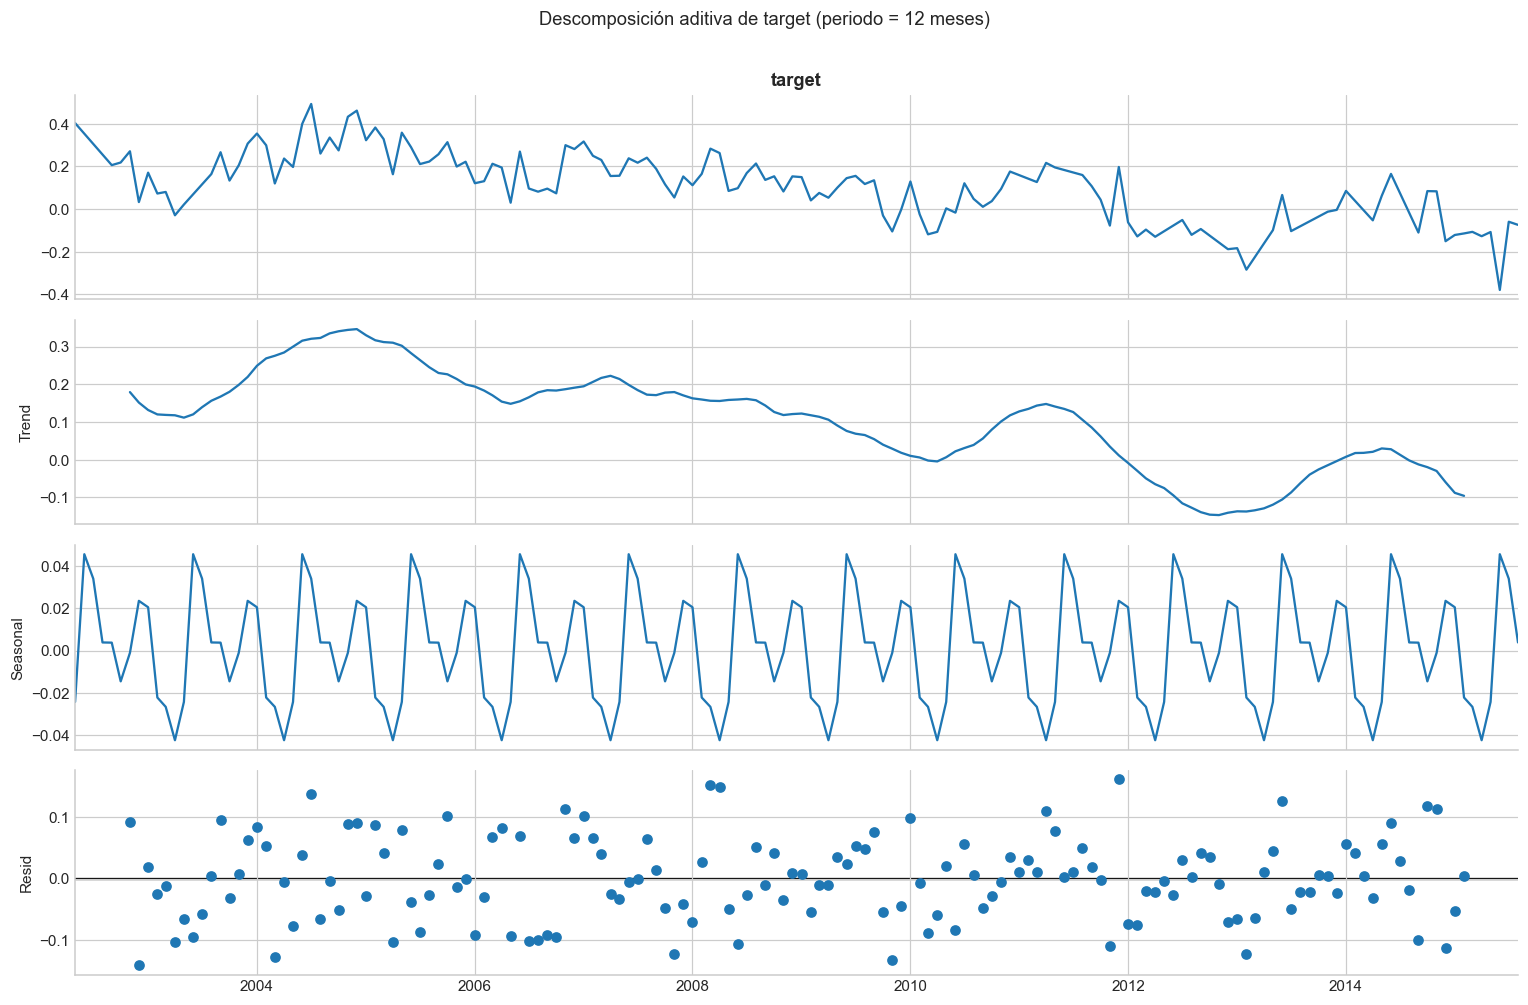


Varianza de la serie      : 0.0255
Varianza de la tendencia  : 0.0162
Varianza estacional       : 0.0007
Varianza del residuo      : 0.0046


In [33]:
# Descomposición de la serie global. Requiere una serie sin huecos y con
# frecuencia declarada.
serie_ts = serie_global.asfreq("MS")
print(f"Meses en la serie: {len(serie_ts)}   Faltantes: {serie_ts.isna().sum()}")

if serie_ts.isna().any():
    serie_ts = serie_ts.interpolate(method="time")
    print("Se interpolaron los meses faltantes únicamente para poder descomponer la serie.")

descomposicion = seasonal_decompose(serie_ts, model="additive", period=12)
fig = descomposicion.plot()
fig.set_size_inches(14, 9)
fig.suptitle(f"Descomposición aditiva de {COL_OBJETIVO} (periodo = 12 meses)", y=1.01)
plt.tight_layout()
guardar_figura("17_descomposicion")
plt.show()

# Magnitud relativa de cada componente.
var_total = serie_ts.var()
print(f"\nVarianza de la serie      : {var_total:.4f}")
print(f"Varianza de la tendencia  : {descomposicion.trend.var():.4f}")
print(f"Varianza estacional       : {descomposicion.seasonal.var():.4f}")
print(f"Varianza del residuo      : {descomposicion.resid.var():.4f}")

In [34]:
# Prueba de Dickey-Fuller aumentada, igual que en el ejemplo de clase.
print("Resultados del Test de Dickey-Fuller para la serie global")
prueba = adfuller(serie_ts.dropna(), autolag="AIC")
salida = pd.Series(prueba[0:4],
                   index=["Estadístico de prueba", "p-value",
                          "# de retardos usados", "# de observaciones usadas"])
for clave, valor in prueba[4].items():
    salida[f"Valor crítico ({clave})"] = valor
display(salida.to_frame("valor"))

p_valor = prueba[1]
if p_valor < 0.05:
    veredicto = ("El p-value es menor a 0.05, por lo que se rechaza la hipótesis nula de raíz "
                 "unitaria: no hay evidencia de que la serie sea no estacionaria en media.")
else:
    veredicto = ("El p-value es mayor a 0.05, por lo que no se puede rechazar la hipótesis nula "
                 "de raíz unitaria: la serie no parece estacionaria en media.")
display(Markdown(f"**Interpretación.** {veredicto}"))

Resultados del Test de Dickey-Fuller para la serie global


,valor
Estadístico de prueba,-1.5158
p-value,0.5257
# de retardos usados,4.0000
# de observaciones usadas,155.0000
Valor crítico (1%),-3.4733
Valor crítico (5%),-2.8804
Valor crítico (10%),-2.5768


**Interpretación.** El p-value es mayor a 0.05, por lo que no se puede rechazar la hipótesis nula de raíz unitaria: la serie no parece estacionaria en media.

### 17.1 Lectura de la estacionalidad

El resultado de esta sección es, quizá, el más contraintuitivo del análisis y
merece explicarse con cuidado.

**En la serie global la estacionalidad es prácticamente inexistente.** La
descomposición reparte la varianza así: tendencia 0.0162, residuo 0.0046 y
componente estacional apenas **0.0007**, sobre una varianza total de 0.0255. Es
decir, el ciclo anual explica alrededor del **3 %** de la variabilidad, mientras
que la tendencia explica cerca del 64 %.

**Esto no significa que el almacenamiento de agua no tenga ciclo anual.** La tabla
del perfil mensual muestra por qué: en el hemisferio norte el promedio es positivo
los doce meses (entre 0.091 en abril y 0.185 en junio), mientras que en el sur es
negativo o cercano a cero casi todo el año (entre −0.105 en junio y 0.025 en
enero). Los dos hemisferios tienen estaciones **opuestas**, de modo que al
promediarlos en una sola serie global sus ciclos se cancelan parcialmente. A esto
se suma el desbalance ya documentado: con el 80 % de las celdas en el norte, la
serie global es en buena medida la serie del hemisferio norte.

La lección metodológica es directa: **una serie agregada globalmente no es el
objeto adecuado para estudiar la estacionalidad de este fenómeno**. La
estacionalidad hay que buscarla por región, y en la sección 18 se confirma que
existe y es sustancial a nivel de banda de latitud.

**La serie no es estacionaria en media.** La prueba de Dickey-Fuller aumentada
arroja un estadístico de −1.516 con p-value de **0.5257**, muy por encima de 0.05,
por lo que no se rechaza la hipótesis nula de raíz unitaria. Este resultado es
coherente con la tendencia descendente identificada en la sección 16: una serie
con tendencia no es estacionaria. Para un modelo que lo requiera habrá que
diferenciar la serie o incorporar la tendencia explícitamente, tal como se hizo en
el ejemplo de series de tiempo visto en clase.

> **Nota sobre la interpolación.** Para poder descomponer la serie fue necesario
> rellenar los 22 meses ausentes, ya que `seasonal_decompose` no admite huecos. La
> interpolación se usa **solo** para esta descomposición y no se propaga al resto
> del análisis; conviene recordarlo al leer la componente de tendencia en esos
> tramos.

## 18. Análisis espacial

El conjunto de datos es una rejilla global, de modo que cada observación tiene
coordenadas. Esto permite responder una pregunta que el promedio global no puede:
¿el comportamiento temporal es parecido en todas partes, o hay regiones que se
mueven en sentido contrario?

Se construyen mapas sencillos reorganizando la rejilla con `pivot_table` y
dibujándola con `imshow`, el mismo recurso usado en los ejemplos de datos
satelitales del curso.

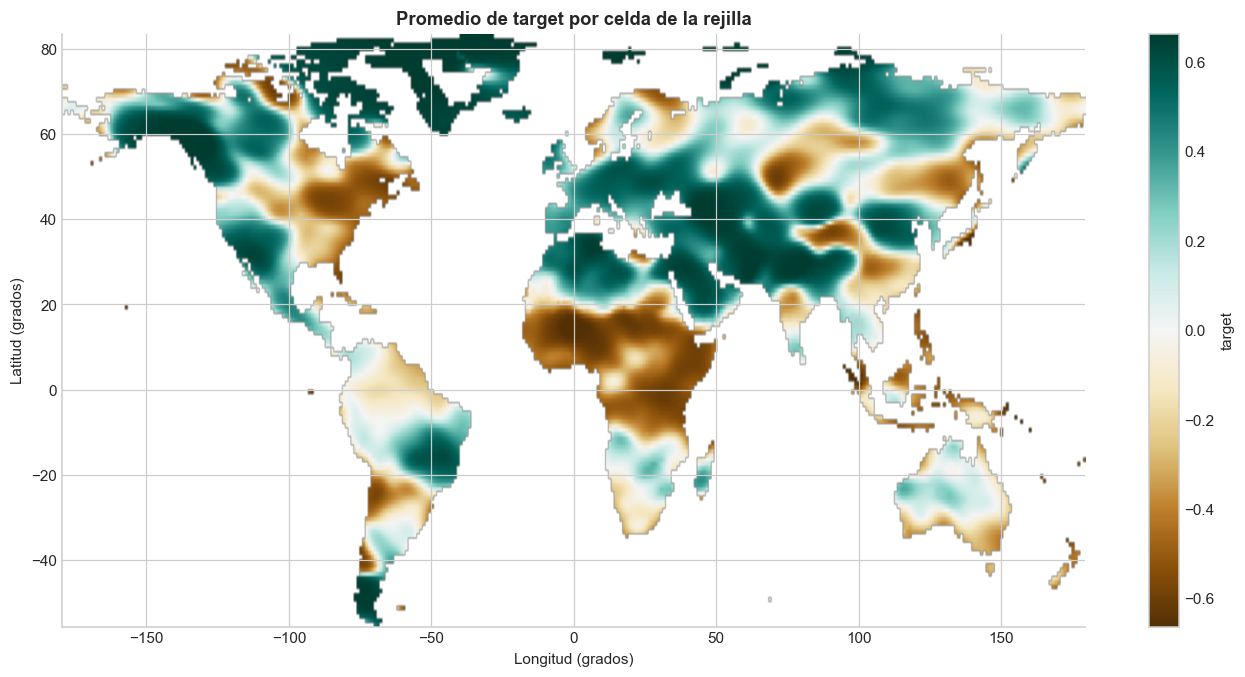

In [35]:
def mapa(valores, titulo, etiqueta, cmap="BrBG", simetrico=True):
    'Dibuja una rejilla lat-lon como mapa. valores: DataFrame indexado por lat y lon.'
    rejilla = valores.pivot_table(index=COL_LAT, columns=COL_LON, values=valores.columns[-1])
    fig, ax = plt.subplots(figsize=(15, 7))
    limite = np.nanpercentile(np.abs(rejilla.values), 98) if simetrico else None
    im = ax.imshow(
        rejilla.values,
        extent=[rejilla.columns.min(), rejilla.columns.max(),
                rejilla.index.min(), rejilla.index.max()],
        origin="lower", aspect="auto", cmap=cmap,
        vmin=-limite if simetrico else None,
        vmax=limite if simetrico else None,
    )
    ax.set(title=titulo, xlabel="Longitud (grados)", ylabel="Latitud (grados)")
    fig.colorbar(im, ax=ax, label=etiqueta)
    return fig, ax


promedio_celda = (
    df.groupby([COL_LAT, COL_LON], observed=True)[COL_OBJETIVO]
      .mean().reset_index()
)
mapa(promedio_celda, f"Promedio de {COL_OBJETIVO} por celda de la rejilla", COL_OBJETIVO)
guardar_figura("18_mapa_promedio")
plt.show()

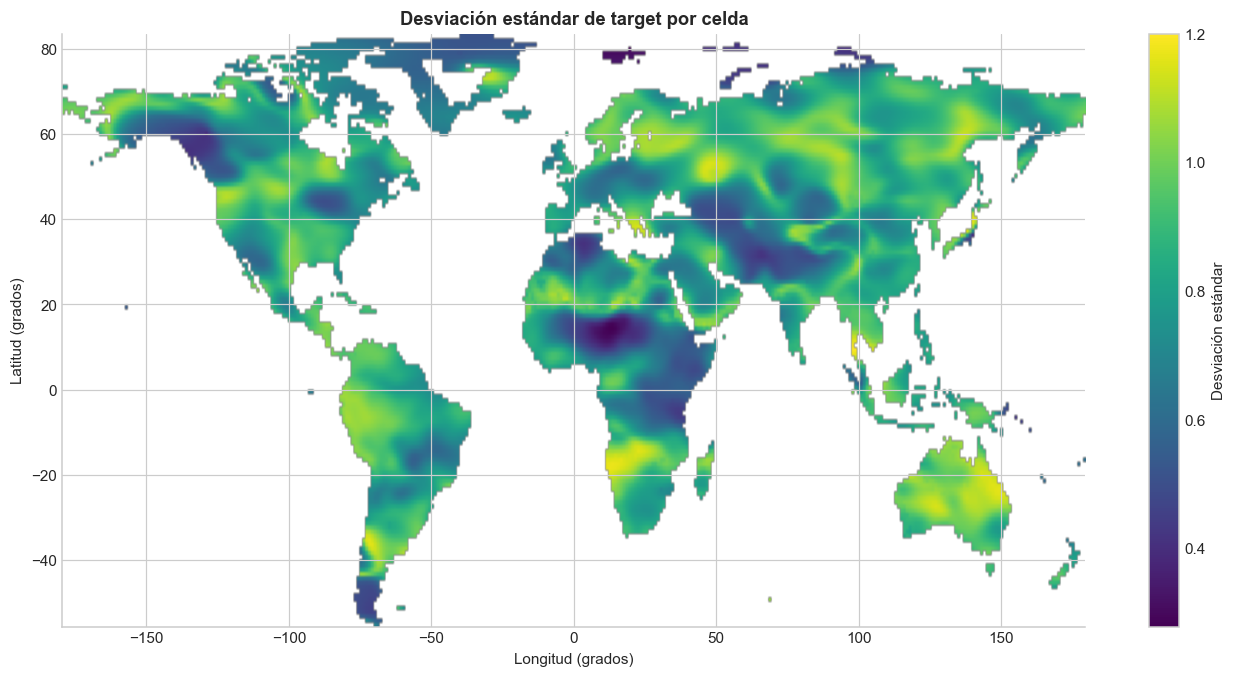

In [36]:
# Variabilidad: dónde el almacenamiento oscila más a lo largo del periodo.
desviacion_celda = (
    df.groupby([COL_LAT, COL_LON], observed=True)[COL_OBJETIVO]
      .std().reset_index()
)
mapa(desviacion_celda, f"Desviación estándar de {COL_OBJETIVO} por celda",
     "Desviación estándar", cmap="viridis", simetrico=False)
guardar_figura("18_mapa_variabilidad")
plt.show()

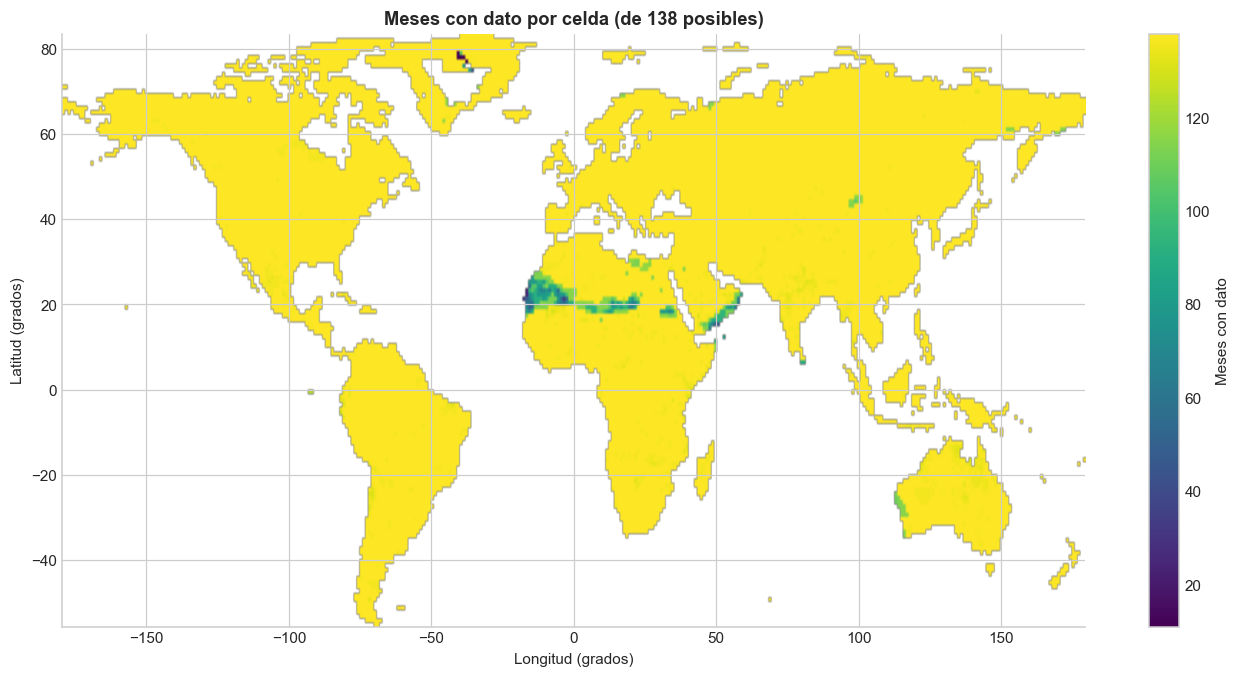

In [37]:
# Cobertura: cuántos de los meses observados tiene cada celda.
cobertura_celda = (
    df.groupby([COL_LAT, COL_LON], observed=True)
      .size().rename("meses_con_dato").reset_index()
)
mapa(cobertura_celda, f"Meses con dato por celda (de {df[COL_FECHA].nunique()} posibles)",
     "Meses con dato", cmap="viridis", simetrico=False)
guardar_figura("18_mapa_cobertura")
plt.show()

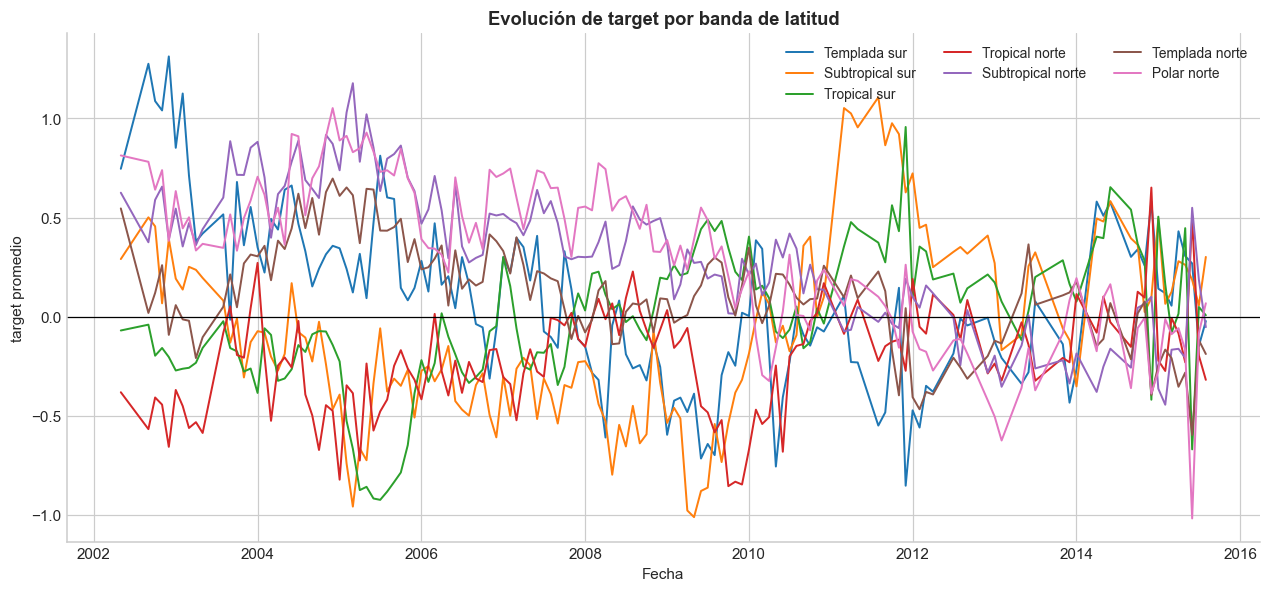

,observaciones,media,mediana,desviacion,minimo,maximo
banda_latitud,,,,,,
Templada sur,38188,0.0887,0.1828,0.9406,-2.9056,3.2168
Subtropical sur,118237,-0.0849,-0.1941,0.9438,-3.0482,3.5948
Tropical sur,267636,-0.0219,-0.0665,0.9278,-3.3437,3.7775
Tropical norte,307545,-0.2221,-0.2941,0.8547,-3.9683,4.0573
Subtropical norte,223897,0.3269,0.3921,0.8447,-3.4659,4.0267
Templada norte,662020,0.1200,0.1639,0.9159,-3.6869,3.4176
Polar norte,536498,0.3178,0.3890,0.8693,-3.1877,3.8758


In [38]:
# Comparación de la evolución temporal entre bandas de latitud.
series_banda = df.pivot_table(index=COL_FECHA, columns="banda_latitud",
                              values=COL_OBJETIVO, aggfunc="mean", observed=True)

fig, ax = plt.subplots(figsize=(14, 6))
for columna in series_banda.columns:
    ax.plot(series_banda.index, series_banda[columna], label=str(columna), linewidth=1.3)
ax.axhline(0, color="black", linewidth=0.8)
ax.set(title=f"Evolución de {COL_OBJETIVO} por banda de latitud",
       xlabel="Fecha", ylabel=f"{COL_OBJETIVO} promedio")
ax.legend(ncol=3, fontsize=9)
guardar_figura("18_series_por_banda")
plt.show()

resumen_banda = df.groupby("banda_latitud", observed=True)[COL_OBJETIVO].agg(
    observaciones="count", media="mean", mediana="median", desviacion="std",
    minimo="min", maximo="max"
)
display(resumen_banda)
resumen_banda.to_csv(TABLAS / "resumen_por_banda_latitud.csv")

### 18.1 Lectura del comportamiento espacial

**El promedio global esconde diferencias regionales grandes y de signo opuesto.**
La tabla por bandas de latitud lo muestra con claridad: la banda **tropical norte
tiene la media más baja (−0.222)**, mientras que la **subtropical norte (0.327)** y
la **polar norte (0.318)** tienen las más altas. Entre los extremos hay una
diferencia de más de medio punto en la escala estandarizada, comparable a la mitad
de una desviación estándar de la variable. Una única serie global promedia
regiones que se comportan de forma distinta.

**La variabilidad también es desigual.** Las bandas tropical norte, subtropical
norte y polar norte tienen desviaciones menores (0.845 a 0.869) que las bandas del
hemisferio sur (0.928 a 0.944). Los valores más extremos de todo el conjunto
—mínimo −3.968 y máximo 4.057— se registran ambos en la banda tropical norte, que
es a la vez la de menor media: es la región donde ocurren las anomalías más
pronunciadas en ambos sentidos.

**Los mapas confirman que la estructura espacial es coherente**, no ruido: las
celdas vecinas presentan valores parecidos y se distinguen regiones continuas de
valores altos y bajos. Esa continuidad espacial es información aprovechable para
un modelo futuro.

El mapa de cobertura, por su parte, muestra que las celdas con series incompletas
no están repartidas al azar sino concentradas en zonas concretas, lo que refuerza
la idea de que los faltantes de este conjunto son estructurales y no aleatorios.

## 19. Correlaciones

Se calcula la matriz de correlación de **Pearson**, apropiada porque las
variables son continuas y el interés está en relaciones lineales. Se acompaña con
la correlación de **Spearman**, que al basarse en rangos detecta relaciones
monótonas aunque no sean lineales; la comparación entre ambas indica si alguna
relación importante es no lineal.

> A lo largo de esta sección se habla de **asociación**, nunca de causa. Que dos
> variables se muevan juntas no demuestra que una determine a la otra.

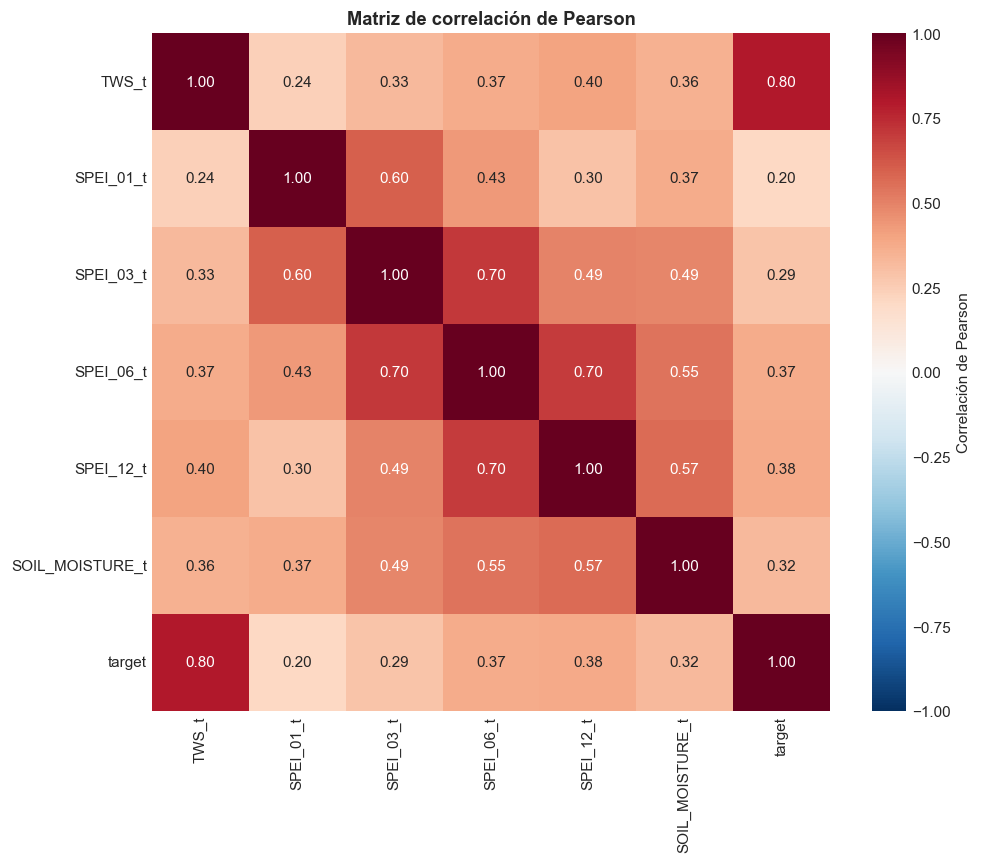

In [39]:
correlacion_pearson = df[COLS_NUMERICAS].corr(method="pearson")

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(correlacion_pearson, annot=True, fmt=".2f", cmap="RdBu_r",
            vmin=-1, vmax=1, center=0, square=True,
            cbar_kws={"label": "Correlación de Pearson"}, ax=ax)
ax.set(title="Matriz de correlación de Pearson")
guardar_figura("19_matriz_correlacion")
plt.show()

correlacion_pearson.to_csv(TABLAS / "correlacion_pearson.csv")

In [40]:
# Muestra para Spearman: sobre 2 millones de filas el cálculo por rangos es lento
# y una muestra aleatoria grande da una estimación equivalente.
muestra = df.sample(n=min(200_000, len(df)), random_state=SEMILLA)
correlacion_spearman = muestra[COLS_NUMERICAS].corr(method="spearman")

comparacion = pd.DataFrame({
    "Pearson": correlacion_pearson[COL_OBJETIVO],
    "Spearman": correlacion_spearman[COL_OBJETIVO],
}).drop(index=COL_OBJETIVO)
comparacion["diferencia"] = (comparacion["Spearman"] - comparacion["Pearson"]).round(3)
comparacion = comparacion.reindex(comparacion["Pearson"].abs().sort_values(ascending=False).index)
display(comparacion.round(4))

display(Markdown(
    "**Lectura.** La columna `diferencia` señala qué relaciones cambian al pasar de "
    "Pearson a Spearman: una diferencia grande sugiere que la asociación existe pero "
    "no es lineal."
))

,Pearson,Spearman,diferencia
TWS_t,0.8033,0.8099,0.0070
SPEI_12_t,0.3796,0.3635,-0.0160
SPEI_06_t,0.3682,0.3522,-0.0160
SOIL_MOISTURE_t,0.3205,0.2963,-0.0240
SPEI_03_t,0.2854,0.2742,-0.0110
SPEI_01_t,0.2039,0.1960,-0.0080


**Lectura.** La columna `diferencia` señala qué relaciones cambian al pasar de Pearson a Spearman: una diferencia grande sugiere que la asociación existe pero no es lineal.

In [41]:
# Asociación de la variable objetivo con el almacenamiento del mes actual.
# Es la relación más importante del problema: mide cuánta inercia tiene la serie.
if COL_TWS is not None:
    correlacion_persistencia = df[[COL_TWS, COL_OBJETIVO]].corr().iloc[0, 1]
    print(f"Correlación entre {COL_TWS} (mes t) y {COL_OBJETIVO} (mes t+1): {correlacion_persistencia:.4f}")

    # La misma relación calculada dentro de cada banda de latitud.
    por_banda = (
        df.groupby("banda_latitud", observed=True)[[COL_TWS, COL_OBJETIVO]]
          .corr().iloc[0::2, 1].reset_index(level=1, drop=True)
          .rename(f"corr({COL_TWS}, {COL_OBJETIVO})")
    )
    display(por_banda.to_frame().round(4))

Correlación entre TWS_t (mes t) y target (mes t+1): 0.8033


,"corr(TWS_t, target)"
banda_latitud,
Templada sur,0.7912
Subtropical sur,0.8056
Tropical sur,0.8195
Tropical norte,0.7523
Subtropical norte,0.7776
Templada norte,0.8243
Polar norte,0.7666


### 19.1 La línea base de persistencia

Si el almacenamiento de un mes predice bien el del mes siguiente, entonces la
regla más simple posible —«mañana será como hoy»— ya es un pronóstico decente.
Esa regla se llama **línea base de persistencia** y es la referencia contra la
cual debe medirse cualquier modelo: un modelo que no la supere no aporta nada.

Como la métrica del reto es el RMSE, se calcula aquí el RMSE que obtendría esa
regla sobre el conjunto de entrenamiento.

RMSE de la persistencia : 0.5724
MAE  de la persistencia : 0.4045
Desviación de target   : 0.9120

El error de la persistencia equivale al 62.8% de la desviación estándar de la variable objetivo.


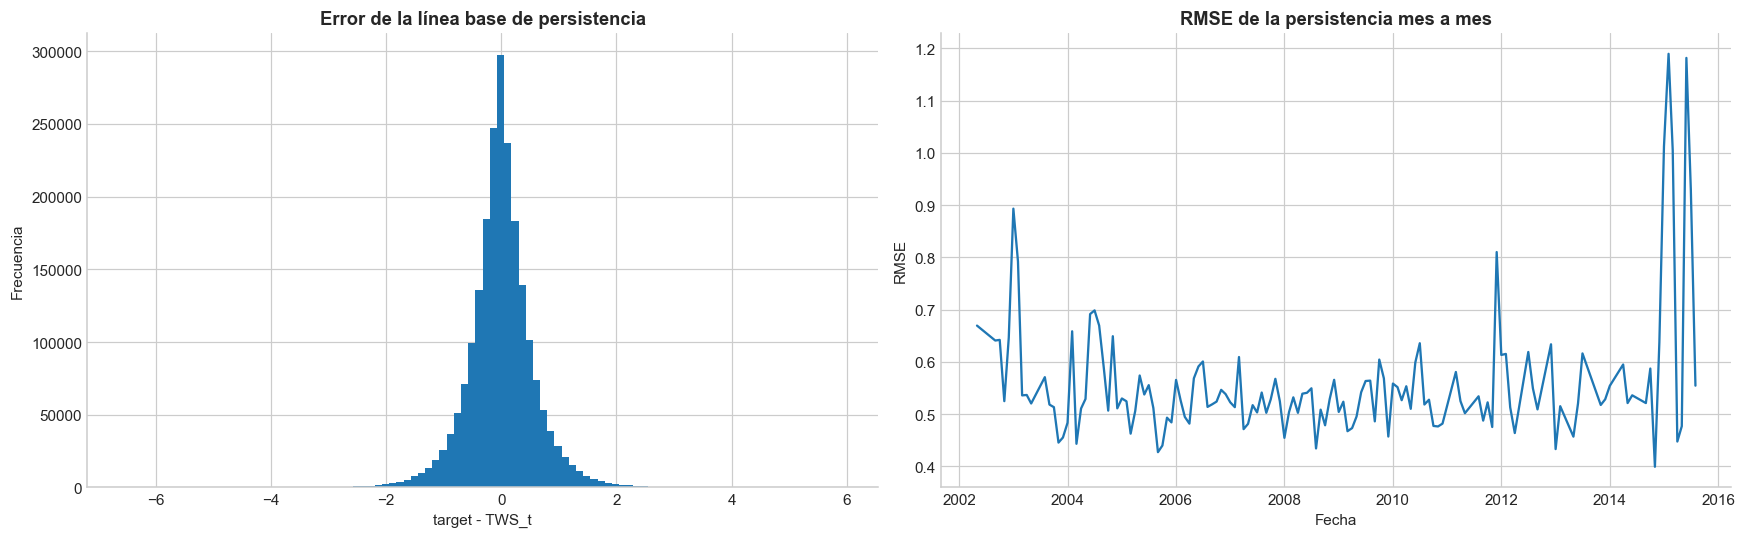

In [42]:
if COL_TWS is not None:
    error_persistencia = df[COL_OBJETIVO] - df[COL_TWS]
    rmse_persistencia = np.sqrt((error_persistencia ** 2).mean())
    mae_persistencia = error_persistencia.abs().mean()

    print(f"RMSE de la persistencia : {rmse_persistencia:.4f}")
    print(f"MAE  de la persistencia : {mae_persistencia:.4f}")
    print(f"Desviación de {COL_OBJETIVO}   : {df[COL_OBJETIVO].std():.4f}")
    print(f"\nEl error de la persistencia equivale al "
          f"{rmse_persistencia / df[COL_OBJETIVO].std() * 100:.1f}% de la desviación "
          f"estándar de la variable objetivo.")

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    axes[0].hist(error_persistencia, bins=100)
    axes[0].set(title="Error de la línea base de persistencia",
                xlabel=f"{COL_OBJETIVO} - {COL_TWS}", ylabel="Frecuencia")

    rmse_mensual = (
        error_persistencia.groupby(df[COL_FECHA])
        .apply(lambda e: np.sqrt((e ** 2).mean()))
    )
    axes[1].plot(rmse_mensual.index, rmse_mensual.values)
    axes[1].set(title="RMSE de la persistencia mes a mes",
                xlabel="Fecha", ylabel="RMSE")
    plt.tight_layout()
    guardar_figura("19_linea_base_persistencia")
    plt.show()

### 19.2 Lectura de las asociaciones

**La persistencia domina todo lo demás.** La correlación entre `TWS_t` y `target`
es **0.803**, más del doble que la de cualquier otra variable. El agua almacenada
tiene mucha inercia: el mejor predictor del mes siguiente es el mes actual. Esta
asociación se mantiene alta en todas las regiones, entre **0.752** en la banda
tropical norte y **0.824** en la templada norte, de modo que es una propiedad
general del fenómeno y no de una zona particular.

**El orden de los SPEI confirma la hipótesis planteada en la sección 2.6.** Las
correlaciones con la variable objetivo se ordenan exactamente según la escala de
acumulación:

| Variable | Correlación con `target` |
| --- | ---: |
| `SPEI_12_t` | 0.380 |
| `SPEI_06_t` | 0.368 |
| `SOIL_MOISTURE_t` | 0.320 |
| `SPEI_03_t` | 0.285 |
| `SPEI_01_t` | 0.204 |

Cuanto más largo es el periodo que acumula el índice, más se asocia con el
almacenamiento total de agua. Es coherente con el argumento físico de que el TWS
integra componentes de respuesta lenta —sobre todo agua subterránea— y por lo
tanto refleja el balance acumulado de muchos meses, no la lluvia del mes en curso.
Conviene subrayar que esto **se planteó como expectativa a verificar y los datos
la respaldan**; no se dio por supuesto.

**Las relaciones son esencialmente lineales.** Las correlaciones de Spearman
difieren de las de Pearson en 0.024 como máximo. Si alguna asociación fuera
fuertemente no lineal, el coeficiente por rangos sería bastante mayor que el de
Pearson, y no es el caso.

**La línea base a superar es exigente.** Predecir simplemente que el mes siguiente
será igual al actual produce un **RMSE de 0.5724** y un MAE de 0.4045, equivalente
al 62.8 % de la desviación estándar de la variable objetivo. Como la métrica del
reto es justamente el RMSE, ese número es la referencia concreta: un modelo que no
baje de 0.5724 no aporta nada sobre la regla trivial.

> Todo lo anterior describe **asociaciones**. Que el SPEI a 12 meses se mueva junto
> al almacenamiento del mes siguiente no demuestra que lo determine; ambos pueden
> responder a un mismo balance hídrico de fondo.

## 20. Cruces de variables

Se seleccionan los cruces que responden preguntas concretas del problema, en
lugar de generar todas las combinaciones posibles. Como el conjunto tiene más de
dos millones de filas, los gráficos de dispersión se construyen sobre una muestra
aleatoria con semilla fija, que preserva la forma de la relación y mantiene la
figura legible.

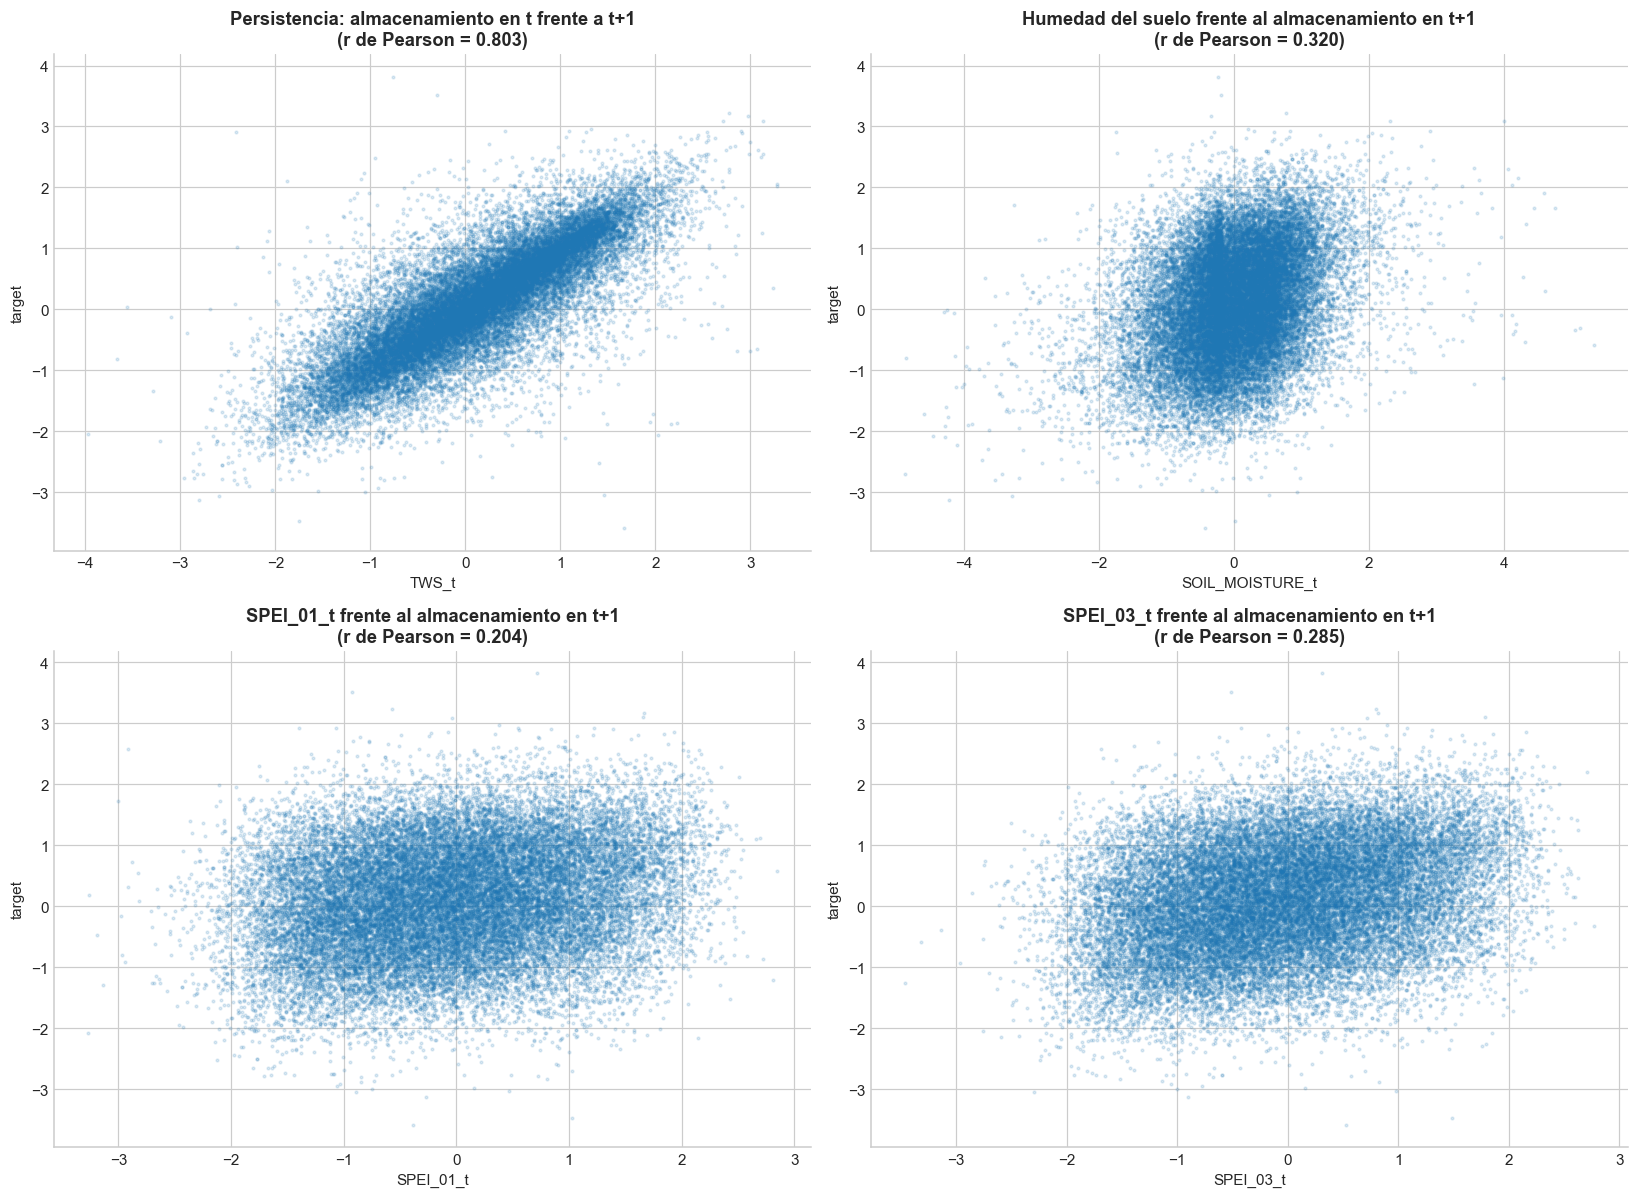

In [43]:
muestra_grafica = df.sample(n=min(30_000, len(df)), random_state=SEMILLA)

pares = []
if COL_TWS is not None:
    pares.append((COL_TWS, COL_OBJETIVO, "Persistencia: almacenamiento en t frente a t+1"))
if COL_SUELO is not None:
    pares.append((COL_SUELO, COL_OBJETIVO, "Humedad del suelo frente al almacenamiento en t+1"))
for c in COLS_SPEI[:2]:
    pares.append((c, COL_OBJETIVO, f"{c} frente al almacenamiento en t+1"))

filas = int(np.ceil(len(pares) / 2))
fig, axes = plt.subplots(filas, 2, figsize=(15, 5.5 * filas))
axes = np.atleast_1d(axes).ravel()

for ax, (x, y, titulo) in zip(axes, pares):
    ax.scatter(muestra_grafica[x], muestra_grafica[y], s=3, alpha=0.15)
    r = df[[x, y]].corr().iloc[0, 1]
    ax.set(title=f"{titulo}\n(r de Pearson = {r:.3f})", xlabel=x, ylabel=y)

for ax in axes[len(pares):]:
    ax.axis("off")

plt.tight_layout()
guardar_figura("20_dispersion_objetivo")
plt.show()

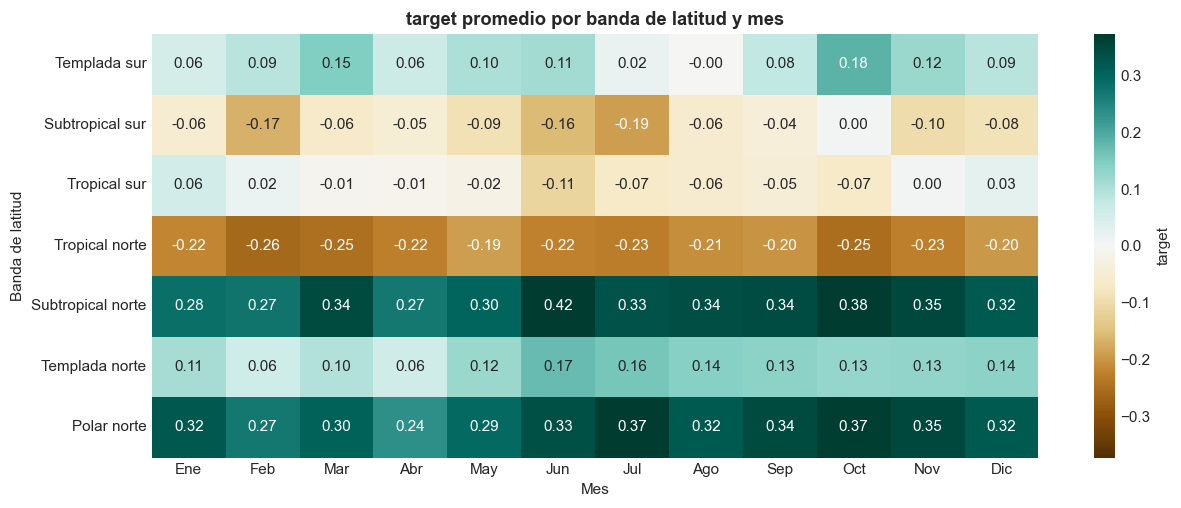

,Ene,Feb,Mar,Abr,May,Jun,Jul,Ago,Sep,Oct,Nov,Dic
banda_latitud,,,,,,,,,,,,
Templada sur,0.0550,0.0880,0.1480,0.0640,0.1030,0.1110,0.0190,-0.0020,0.0800,0.1830,0.1210,0.0900
Subtropical sur,-0.0550,-0.1680,-0.0630,-0.0470,-0.0880,-0.1550,-0.1900,-0.0560,-0.0410,0.0050,-0.0980,-0.0850
Tropical sur,0.0560,0.0170,-0.0100,-0.0130,-0.0230,-0.1130,-0.0670,-0.0570,-0.0460,-0.0660,0.0040,0.0260
Tropical norte,-0.2150,-0.2600,-0.2480,-0.2240,-0.1910,-0.2220,-0.2290,-0.2080,-0.2030,-0.2510,-0.2260,-0.1980
Subtropical norte,0.2830,0.2750,0.3450,0.2680,0.2980,0.4170,0.3310,0.3390,0.3420,0.3760,0.3520,0.3200
Templada norte,0.1090,0.0640,0.0970,0.0600,0.1200,0.1720,0.1600,0.1410,0.1340,0.1280,0.1280,0.1360
Polar norte,0.3210,0.2690,0.3040,0.2360,0.2920,0.3350,0.3710,0.3190,0.3450,0.3680,0.3490,0.3180


In [44]:
# Cruce mes x banda de latitud: dónde y cuándo el almacenamiento es más bajo.
tabla_cruce = df.pivot_table(index="banda_latitud", columns="mes",
                             values=COL_OBJETIVO, aggfunc="mean", observed=True)
tabla_cruce.columns = nombres_mes[:len(tabla_cruce.columns)]

fig, ax = plt.subplots(figsize=(13, 5))
limite = np.nanpercentile(np.abs(tabla_cruce.values), 98)
sns.heatmap(tabla_cruce, annot=True, fmt=".2f", cmap="BrBG", center=0,
            vmin=-limite, vmax=limite, cbar_kws={"label": COL_OBJETIVO}, ax=ax)
ax.set(title=f"{COL_OBJETIVO} promedio por banda de latitud y mes",
       xlabel="Mes", ylabel="Banda de latitud")
guardar_figura("20_cruce_banda_mes")
plt.show()

display(tabla_cruce.round(3))

,observaciones,media,mediana,desviacion
categoria_sequia,,,,
Sequía extrema,"18,812.0000",-0.2853,-0.2436,0.9290
Sequía severa,"104,149.0000",-0.2476,-0.2476,0.9299
Sequía moderada,"248,704.0000",-0.1170,-0.1206,0.9050
Normal,"1,439,913.0000",0.1157,0.1271,0.8939
Húmedo moderado,"209,833.0000",0.3365,0.3730,0.8878
Húmedo severo,"106,623.0000",0.4669,0.5250,0.8921
Húmedo extremo,"25,987.0000",0.6018,0.6804,0.8970


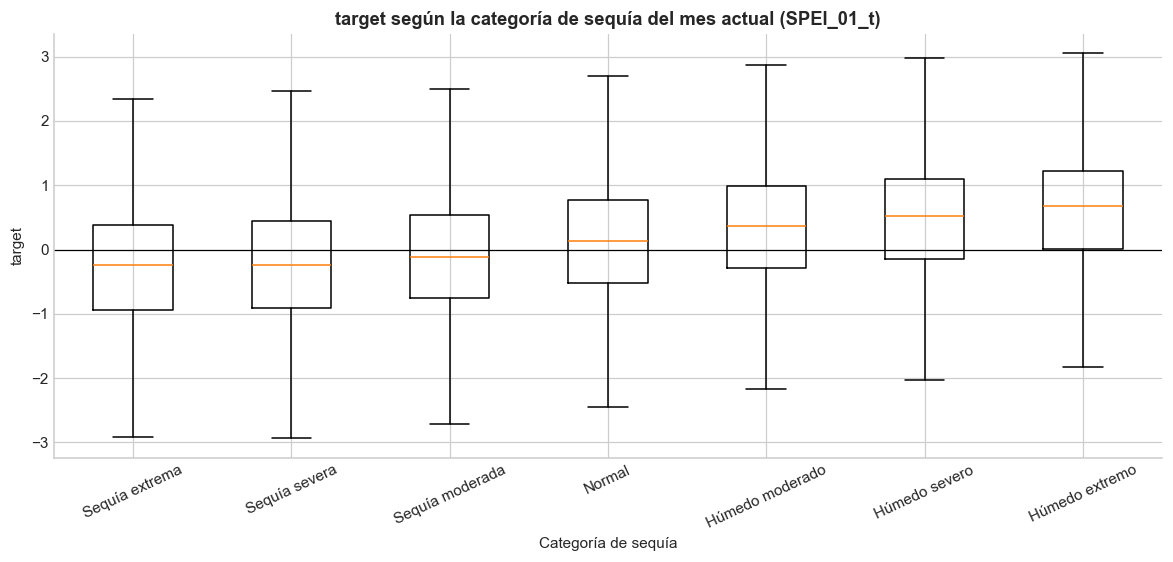

In [45]:
# Relación entre categoría de sequía del SPEI y el almacenamiento del mes siguiente.
if COLS_SPEI:
    resumen_categoria = (
        df.groupby("categoria_sequia", observed=True)[COL_OBJETIVO]
          .agg(observaciones="count", media="mean", mediana="median", desviacion="std")
          .reindex(orden_categorias).dropna(how="all")
    )
    display(resumen_categoria)

    fig, ax = plt.subplots(figsize=(13, 5))
    categorias_presentes = [c for c in orden_categorias if c in df["categoria_sequia"].unique()]
    datos_cat = [df.loc[df["categoria_sequia"] == c, COL_OBJETIVO].dropna().values
                 for c in categorias_presentes]
    ax.boxplot(datos_cat, tick_labels=categorias_presentes, showfliers=False)
    ax.axhline(0, color="black", linewidth=0.8)
    ax.set(title=f"{COL_OBJETIVO} según la categoría de sequía del mes actual ({col_spei_ref})",
           xlabel="Categoría de sequía", ylabel=COL_OBJETIVO)
    ax.tick_params(axis="x", rotation=25)
    guardar_figura("20_objetivo_por_categoria_sequia")
    plt.show()

### 20.1 Lectura de los cruces

**El cruce banda × mes revela la estacionalidad que la serie global ocultaba.** El
mapa de calor muestra patrones mensuales definidos dentro de cada banda: la
subtropical norte alcanza su máximo en junio (0.417) y su mínimo en abril (0.268);
la tropical norte, que es la banda más seca en promedio, tiene su mínimo en
febrero (−0.260) y su máximo en mayo (−0.191). Es decir, **el ciclo anual existe y
es apreciable a nivel regional**, pero se cancela al promediar el planeta entero,
tal como se argumentó en la sección 17.

**La categoría de sequía del mes actual ordena el almacenamiento del mes
siguiente de forma monótona.** La media de `target` crece sin excepción a lo largo
de las siete categorías: −0.285 en sequía extrema, −0.248 en severa, −0.117 en
moderada, 0.116 en normal, 0.337 en húmedo moderado, 0.467 en húmedo severo y
0.602 en húmedo extremo. Que la relación sea monótona en toda la escala refuerza
la utilidad del SPEI como covariable, aunque la dispersión dentro de cada
categoría siga siendo alta (desviaciones entre 0.888 y 0.930), señal de que el
SPEI por sí solo está lejos de determinar el resultado.

**Los gráficos de dispersión confirman visualmente lo que dicen las
correlaciones.** La nube de `TWS_t` frente a `target` se agrupa de forma estrecha
alrededor de la diagonal, mientras que las de los SPEI y la humedad del suelo
frente al objetivo son mucho más difusas.

## 21. Hallazgos principales

Cada hallazgo de esta sección remite a la tabla, la estadística o la figura que lo
respalda. La celda siguiente recopila las cifras clave calculadas en el cuaderno
para que el resumen escrito se apoye en valores verificables.

In [46]:
resumen_final = {
    "Observaciones en train": f"{len(train):,}",
    "Observaciones en test": f"{len(test):,}",
    "Variables en train": train.shape[1],
    "Rango temporal": f"{df[COL_FECHA].min().date()} a {df[COL_FECHA].max().date()}",
    "Meses cubiertos": df[COL_FECHA].nunique(),
    "Celdas de la rejilla": f"{n_celdas:,}",
    "Faltantes en la variable objetivo": f"{df[COL_OBJETIVO].isna().mean()*100:.2f}%",
    "Duplicados exactos": f"{train.duplicated().sum():,}",
    f"Media de {COL_OBJETIVO}": f"{df[COL_OBJETIVO].mean():.4f}",
    f"Desviación de {COL_OBJETIVO}": f"{df[COL_OBJETIVO].std():.4f}",
    "Atípicos por IQR en la objetivo": f"{tabla_atipicos.loc[COL_OBJETIVO, '%_atípicos']:.2f}%",
    "p-value Dickey-Fuller": f"{p_valor:.5f}",
}
if COL_TWS is not None:
    resumen_final[f"corr({COL_TWS}, {COL_OBJETIVO})"] = f"{correlacion_persistencia:.4f}"

tabla_resumen = pd.DataFrame.from_dict(resumen_final, orient="index", columns=["Valor"])
tabla_resumen.index.name = "Indicador"
display(tabla_resumen)
tabla_resumen.to_csv(TABLAS / "resumen_hallazgos.csv")

,Valor
Indicador,
Observaciones en train,"2,154,021"
Observaciones en test,"280,961"
Variables en train,13
Rango temporal,2002-05-01 a 2015-08-01
Meses cubiertos,138
Celdas de la rejilla,"15,715"
Faltantes en la variable objetivo,0.00%
Duplicados exactos,0
Media de target,0.1125


### Los ocho hallazgos del análisis

**1. El conjunto no tiene valores nulos ni duplicados, pero sí faltantes
estructurales importantes.** Las 13 columnas están completas en las 2 154 021
filas y no hay identificadores repetidos. Sin embargo, del periodo 2002-05 a
2015-08 faltan **22 de los 160 meses del calendario (13.8 %)**, meses en los que no
existe ninguna fila. El formato plano —una fila por combinación observada— hace que
un mes no observado desaparezca en lugar de aparecer como `NaN`, y por eso el
conteo de nulos no lo detecta.
*Evidencia: tabla de calidad y lista de meses ausentes, sección 10.*

**2. Los meses ausentes se concentran al inicio y al final del periodo.** Los años
2004 a 2010 están completos, mientras que 2011 a 2014 pierden entre 4 y 5 meses
cada uno y 2002 pierde 3. El patrón es coherente con el deterioro progresivo de la
misión GRACE en sus últimos años de operación, aunque esa atribución proviene de
literatura externa y no puede verificarse con este archivo.
*Evidencia: tabla de cobertura anual y figura `10_cobertura_temporal`.*

**3. La variable objetivo es el almacenamiento del mes calendario `t+1`, no el del
siguiente mes disponible.** La comprobación celda por celda muestra coincidencia
en 1 977 398 filas cuando el salto al registro siguiente es exactamente de un mes,
y **ninguna coincidencia** cuando el salto es mayor. Para las filas cuyo `t+1` cae
en un mes ausente, `target` es la única información existente sobre ese mes.
*Evidencia: tabla de saltos temporales, sección 11.1.*

**4. Las variables están estandarizadas y son adimensionales.** Todas tienen media
próxima a cero y desviación próxima a uno (`target`: media 0.113, desviación
0.912), con distribuciones casi simétricas (asimetrías entre −0.14 y 0.09). No
están en centímetros de lámina de agua, de modo que **no admiten lectura como
volumen físico**.
*Evidencia: tabla de estadística descriptiva, sección 12.*

**5. Hay una tendencia descendente sostenida.** El promedio anual de `target` cae
de 0.322 en 2004 a −0.136 en 2015, y la prueba de Dickey-Fuller no permite
rechazar la raíz unitaria (p = 0.526): la serie **no es estacionaria en media**. La
descomposición atribuye a la tendencia el 64 % de la varianza. El resultado se
sostiene tanto con promedio simple como ponderado por área (correlación 0.936).
*Evidencia: promedios anuales, figura `16_media_movil`, descomposición y prueba ADF.*

**6. La estacionalidad desaparece al agregar globalmente, pero existe a nivel
regional.** La componente estacional explica solo el 3 % de la varianza de la serie
global. La causa es que los hemisferios tienen ciclos opuestos —el norte promedia
positivo los doce meses, el sur negativo o nulo— y se cancelan al promediarse. El
cruce banda × mes muestra ciclos mensuales definidos dentro de cada región.
*Evidencia: perfil estacional por hemisferio, descomposición y figura `20_cruce_banda_mes`.*

**7. El conjunto está fuertemente desbalanceado en el espacio, y las regiones se
comportan de forma distinta.** El 80.3 % de las observaciones corresponde al
hemisferio norte y la banda polar sur no tiene ninguna. La banda tropical norte es
la de menor media (−0.222) y a la vez donde se registran el mínimo y el máximo
absolutos del conjunto; las bandas subtropical y polar norte son las de mayor media
(0.327 y 0.318).
*Evidencia: tablas de frecuencia por banda y hemisferio, y resumen por banda.*

**8. La persistencia domina, y entre las covariables mandan las escalas largas del
SPEI.** La correlación entre `TWS_t` y `target` es 0.803, frente a 0.380 del
`SPEI_12_t`, 0.368 del `SPEI_06_t`, 0.320 de la humedad del suelo, 0.285 del
`SPEI_03_t` y 0.204 del `SPEI_01_t`. El orden por escala de acumulación es exacto y
confirma la expectativa planteada al inicio. La línea base de persistencia obtiene
**RMSE 0.5724**, la referencia que cualquier modelo debe superar.
*Evidencia: matriz de correlación, comparación Pearson-Spearman y sección 19.2.*

## 22. Conclusiones

Las conclusiones se organizan siguiendo los seis objetivos específicos planteados
en la sección 5.2, de modo que pueda verificarse que cada uno quedó cubierto.

**Objetivo 1 — Describir la estructura del conjunto.** El archivo de entrenamiento
contiene 2 154 021 observaciones y 13 variables, y el de prueba 280 961
observaciones. Los datos vienen en formato plano, con una fila por combinación de
mes y celda, sobre una rejilla global de **1° de resolución con 15 715 celdas**
que cubre de −55.5° a 83.5° de latitud. El periodo de entrenamiento va de mayo de
2002 a agosto de 2015. Las variables se clasificaron en identificador
(`sample_id`), temporal (`time`), geográficas (`lat`, `lon`), satelital (`TWS_t`),
climáticas (`SPEI_01_t` a `SPEI_12_t` y `SOIL_MOISTURE_t`), codificación temporal
ya provista (`month_sin`, `month_cos`) y objetivo (`target`).

**Objetivo 2 — Evaluar la calidad de los datos.** No hay valores nulos, ni filas
duplicadas, ni identificadores repetidos. El problema de calidad real es de otra
naturaleza: **faltan 22 meses completos del calendario** y el 0.68 % de las
combinaciones celda-mes. Los valores atípicos por IQR son escasos en la variable
objetivo (0.25 %) y más frecuentes en la humedad del suelo (2.58 %); se
documentaron y **no se eliminaron**, porque se agrupan en años y regiones
concretos, lo que apunta a eventos hidrológicos reales y no a errores.

**Objetivo 3 — Analizar el comportamiento temporal.** La serie presenta una
tendencia descendente sostenida y no es estacionaria en media (Dickey-Fuller,
p = 0.526). La descomposición atribuye el 64 % de la varianza a la tendencia y
solo el 3 % al ciclo anual.

**Objetivo 4 — Comparar entre ubicaciones geográficas.** Las regiones no se
comportan igual: la banda tropical norte promedia −0.222 mientras que la
subtropical norte promedia 0.327. Más importante aún, el análisis por hemisferio
explicó por qué la estacionalidad parecía ausente: los ciclos opuestos del norte y
del sur se cancelan al promediarse. **El promedio global no es representativo del
comportamiento local.**

**Objetivo 5 — Determinar el grado de asociación.** La variable más asociada con
el objetivo es el propio almacenamiento del mes actual (r = 0.803). Entre las
covariables, el orden sigue exactamente la escala de acumulación del SPEI, de 0.380
para 12 meses a 0.204 para 1 mes. Las relaciones son esencialmente lineales, ya
que Pearson y Spearman difieren en 0.024 como máximo.

**Objetivo 6 — Identificar variables candidatas para el modelado.** Se recogen en
la sección 23.

### Limitaciones del conjunto

Conviene ser explícito sobre lo que estos datos **no** permiten:

- Al estar estandarizadas, las variables no admiten interpretación en unidades
  físicas de volumen o de lámina de agua.
- La resolución de 1° describe escalas de cientos de kilómetros; no permite
  conclusiones sobre cuencas pequeñas ni sobre puntos concretos.
- El desbalance hemisférico (80 % / 20 %) hace que cualquier métrica global esté
  dominada por el hemisferio norte.
- El análisis es **descriptivo y asociativo**. En ningún punto se establece
  causalidad, y las correlaciones halladas no deben leerse en ese sentido.
- Los 22 meses ausentes limitan lo que puede afirmarse sobre continuidad temporal
  en 2002-2003 y 2011-2014.

## 23. Próximos pasos

**1. Partir de la persistencia como línea base.** Cualquier modelo debe compararse
contra el RMSE de 0.5724 obtenido por la regla trivial. Es la primera métrica que
debe reportarse.

**2. Construir variables de rezago con cuidado.** El almacenamiento del mes actual
es la variable más informativa, así que los rezagos de `TWS_t` y sus diferencias
son candidatos naturales. Es indispensable **respetar los 22 meses ausentes**: un
`shift()` sobre el índice de filas produciría rezagos falsos, porque el registro
anterior de una celda no siempre corresponde al mes anterior.

**3. Incorporar la dimensión regional.** Dado que el comportamiento difiere por
banda de latitud y por hemisferio, conviene evaluar modelos que reciban esa
información o que se entrenen por región, y **validar por regiones además de
globalmente**. Cabe señalar que el material de la organización advierte que
latitud y longitud no deberían usarse directamente como variables predictoras.

**4. Tratar la tendencia explícitamente.** La serie no es estacionaria. Según el
modelo que se elija, habrá que diferenciar, incluir un término de tendencia o
trabajar sobre residuos, tal como se hizo en el ejemplo de series de tiempo del
curso.

**5. Priorizar las escalas largas del SPEI.** `SPEI_12_t` y `SPEI_06_t` son las
covariables con mayor asociación y deberían entrar antes que `SPEI_01_t`.

**6. Validar respetando el orden temporal.** La partición debe ser cronológica,
nunca aleatoria: una partición al azar dejaría meses futuros en el entrenamiento y
produciría una estimación optimista del error.

**7. Manejar el enmascaramiento del conjunto de prueba.** El 66.53 % de las filas
de prueba tiene `TWS_t` enmascarado a propósito. Como esa es justamente la
variable más predictiva, el modelo debe funcionar sin ella en dos tercios de los
casos, y esa condición debe reproducirse durante la validación para no
sobreestimar el desempeño.

## Referencias

- Zindi / ITU. *A Step Ahead of Drought: Forecasting Global Water Storage Challenge.*
  <https://zindi.world/competitions/one-step-ahead-of-drought-forecasting-global-water-storage-challenge>
- Copernicus European Drought Observatory. *GRACE Total Water Storage (TWS) Anomaly — Factsheet.*
  <https://drought.emergency.copernicus.eu/data/factsheets/factsheet_grace_tws_anomaly.pdf>
- Vicente-Serrano, S. M., Beguería, S. y López-Moreno, J. I. *SPEI: The Standardised
  Precipitation-Evapotranspiration Index.* <https://spei.csic.es/home.html>
- Material del curso CC3084: *Ejemplo series de tiempo LSTM*, *Practica01 Incendios*
  y *EjemploGIS Sentinel2*.